#Manuscript

##Figure 3

Necessary packages

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
from google.colab import files
import math
import random


Without reinsurance formula

In [ ]:
# Define a function
def wo_formula(x, var, cor, delt, num, index):
    # Calculate the covariance matrix with fixed pairwise correlations of (cor)
    correlation = cor
    cov = np.diag(var)
    for i in range(num):
        for j in range(i + 1, num):
            cov[i, j] = cov[j, i] = correlation * np.sqrt(var[i] * var[j])

    #Parameters
    sum_sd = np.sum(np.sqrt(var))  #\Sigma_n
    total_var = np.sum(cov)  #s_n^2
    lam_ni = delt[index]/np.sum(delt[:num]) #lambda_n,i
    lam_n1i = delt[index]/np.sum(delt) #lambda_n+1,i
    func=x**2+2*cor*(sum_sd-np.sqrt(var[index])/lam_n1i)*x+2*(lam_ni/(lam_n1i**2)-1/lam_n1i)*(var[index]+cor*np.sqrt(var[index])*(sum_sd-np.sqrt(var[index])))-((lam_ni**2)/(lam_n1i**2)-1)*total_var

    return func

With Reinsurance montecarlo

In [ ]:
def wi_monte(data, K, n):
    x_values = data[:, 0]
    y_values = data[:, 1]
    y_values_trun = np.array([min(element, K) for element in y_values])

    fn1= np.log(np.mean(np.exp(y_values_trun/n)))
    fn2= np.mean(x_values * np.exp(y_values_trun / n))/np.mean(np.exp(y_values_trun/n))
    fn3= np.mean(y_values * np.exp(y_values_trun / n))/np.mean(np.exp(y_values_trun/n))*(1/n)
    fn4= np.mean([max(element-K,0) for element in y_values])*(1/n)

    result=fn1+fn2-fn3+fn4
    return result

Get sample for reinsurance case

In [ ]:
def get_sample_wR(s3,mean,var,beta, rho,size_sample):

    s1=np.sqrt(var[0])
    s2=np.sqrt(var[1])
    u1=mean[0]
    u2=mean[1]
    u3=mean[2]

    k2=u1+u2+beta*np.sqrt(s1**2+s2**2+2*rho*(s1*s2))
    k3=u1+u2+u3+beta*np.sqrt(s1**2+s2**2+s3**2+2*rho*(s1*s2+s2*s3+s3*s1))

    # Parameters for the bivariate normal distribution with n, X1 and Sn
    mean_vector = np.array([u1, u1+u2])
    covariance_matrix = np.array([[s1**2, s1**2+rho*s1*s2], [s1**2+rho*s1*s2, s1**2+s2**2+2*rho*s1*s2]])

    # Generate random samples from the normal distribution with n, X1 and Sn
    samples_n = multivariate_normal.rvs(mean=mean_vector, cov=covariance_matrix, size=size_sample)

    # Parameters for the bivariate normal distribution with n+1, X1 and Sn
    mean_vector1 = np.array([u1, u1+u2+u3])
    covariance_matrix1 = np.array([[s1**2, s1**2+rho*s1*s2+rho*s1*s3], [s1**2+rho*s1*s2+rho*s1*s3, s1**2+s2**2+s3**2+2*rho*(s1*s2+s2*s3+s3*s1)]])

    # Generate random samples from the normal distribution with n+1, X1 and Sn
    samples_n1 = multivariate_normal.rvs(mean=mean_vector1, cov=covariance_matrix1, size=size_sample)

    return samples_n, samples_n1, k2, k3

Simulation, homogeneous risk case, two agents, for different $\beta$s

Parameters

In [ ]:
#Parameters
Nsamplesize = 1000
Amean = np.array([0,0,0],dtype=float)
Avar = np.array([1,1],dtype=float)
Adeltas = np.array([1,1,1],dtype=float)
Ncorr = 0.2
Nexist = 2
As3=np.linspace(0,10,100)
Abeta=[1,1.64,1.96, 2.57]
trial = 1000

Without Reinsurance

In [ ]:
# condition
x = np.linspace(0, 10, 100)
y1 = wo_formula(x, Avar, Ncorr, Adeltas, 2, 0)/18

With Reinsurance

In [ ]:
result_homo_beta = []

for Nbeta in Abeta:
    result_temp = np.zeros(len(As3), dtype=float)

    for i in range(trial):
        result_temp2 = []

        for s3 in As3:

            # samples
            Asample_XiSn, Asample_XiSn1, k2, k3 = get_sample_wR(s3, Amean, Avar, Nbeta, Ncorr, Nsamplesize)

            # Utility with insurance
            U_n=wi_monte(Asample_XiSn,k2,2)
            U_n1=wi_monte(Asample_XiSn1,k3,3)
            result_temp2.append(U_n-U_n1)

        result_temp += np.array(result_temp2, dtype=float)/trial
    result_homo_beta.append(result_temp)


Plot with and without reinsurance (Figure 3.b.)

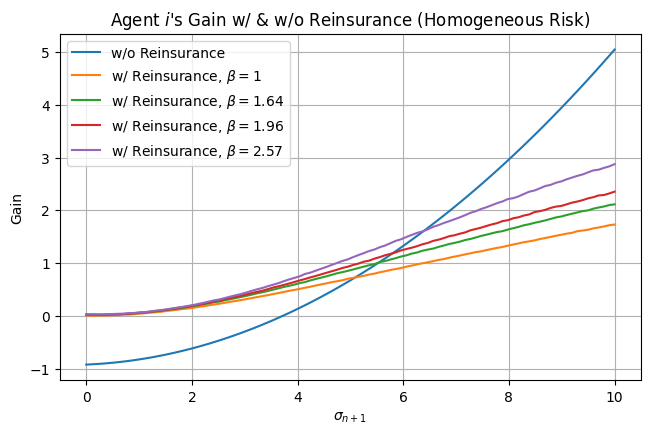

In [ ]:
#Plot all together

plt.figure(figsize=(7.5, 4.5))

# Plot, w/o R function
plt.plot(As3,y1,label='w/o Reinsurance')

# Create a plot, w/ R Monte Carlo
for i in range(len(Abeta)):
    plt.plot(As3,result_homo_beta[i], label=r'w/ Reinsurance, $\beta={}$'.format(Abeta[i]))

plt.legend()
plt.xlabel(r'$\sigma_{n+1}$')
plt.ylabel('Gain')
plt.title(r"Agent $i$'s Gain w/ & w/o Reinsurance (Homogeneous Risk)")
plt.grid(True)
plt.show()

Simulation, homogeneous risk case, two agents, for different $\rho$s

Parameters

In [ ]:
#Parameters
Nsamplesize = 1000
Amean = np.array([0,0,0],dtype=float)
Avar = np.array([1,1],dtype=float)
Adeltas = np.array([1,1,1],dtype=float)
Ncorr = 0.2
Nexist = 2
As3=np.linspace(0,10,100)
Nbeta=1.64
Acorr = [0.1,0.5,0.9]
trial = 1000

Without Reinsurance

In [ ]:
result_homo_rho_wo = []
for rho in Acorr:
    result_homo_rho_wo.append(wo_formula(As3, Avar, rho, Adeltas, 2, 0)/18)

With Reinsurance

In [ ]:
result_homo_rho = []

for rho in Acorr:
    result_temp = np.zeros(len(As3), dtype=float)

    for i in range(trial):
        result_temp2 = []

        for s3 in As3:

            # samples
            Asample_XiSn, Asample_XiSn1, k2, k3 = get_sample_wR(s3, Amean, Avar, Nbeta, rho, Nsamplesize)

            # Utility with insurance
            U_n=wi_monte(Asample_XiSn,k2,2)
            U_n1=wi_monte(Asample_XiSn1,k3,3)
            result_temp2.append(U_n-U_n1)

        result_temp += np.array(result_temp2, dtype=float)/trial
    result_homo_rho.append(result_temp)

(Figure 3.a.)

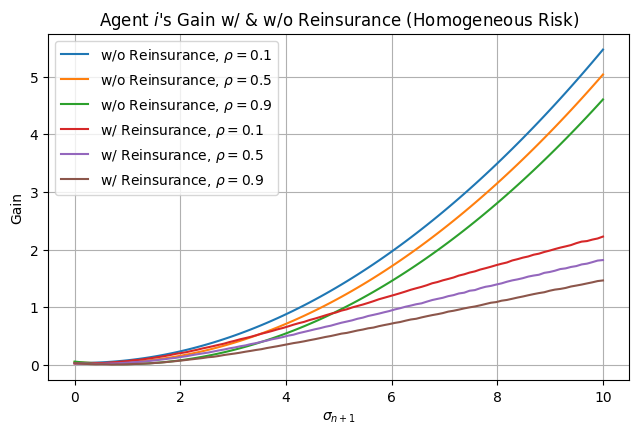

In [ ]:
#Plot all together
plt.figure(figsize=(7.5, 4.5))

# Plot, w/o R function
for i in range(len(result_homo_rho_wo)):
    plt.plot(As3,result_homo_rho_wo[i],label=r'w/o Reinsurance, $\rho={}$'.format(Acorr[i]))

# Create a plot, w/ R Monte Carlo
for i in range(len(result_homo_rho)):
    plt.plot(As3,result_homo_rho[i], label=r'w/ Reinsurance, $\rho={}$'.format(Acorr[i]))

plt.legend()
plt.xlabel(r'$\sigma_{n+1}$')
plt.ylabel('Gain')
plt.title(r"Agent $i$'s Gain w/ & w/o Reinsurance (Homogeneous Risk)")
plt.grid(True)
# plt.savefig('20231222_equi_strong_wwoR_compare_homo_r.jpg')
plt.show()
# files.download('20231222_equi_strong_wwoR_compare_homo_r.jpg')

Simulation, heterogeneous risk case, two agents, my risk big

Parameters

In [ ]:
#Parameters
Nsamplesize = 1000
Amean = np.array([0,0,0],dtype=float)
Avar = np.array([15,1],dtype=float)
Adeltas = np.array([1,1,1],dtype=float)
Ncorr = 0.2
Nexist = 2
As3=np.linspace(0,10,100)
Abeta=[1,1.64,1.96, 2.57]
Ncorr = 0.2
trial = 1000

Without Reinsurance

In [ ]:
# condition
x = np.linspace(0, 10, 100)
y1 = wo_formula(x, Avar, Ncorr, Adeltas, 2, 0)/18

With Reinsurance

In [ ]:
result_hetero_beta = []

for beta in Abeta:
    result_temp = np.zeros(len(As3), dtype=float)

    for i in range(trial):
        result_temp2 = []

        for s3 in As3:

            # samples
            Asample_XiSn, Asample_XiSn1, k2, k3 = get_sample_wR(s3, Amean, Avar, beta, Ncorr, Nsamplesize)

            # Utility with insurance
            U_n=wi_monte(Asample_XiSn,k2,2)
            U_n1=wi_monte(Asample_XiSn1,k3,3)
            result_temp2.append(U_n-U_n1)

        result_temp += np.array(result_temp2, dtype=float)/trial
    result_hetero_beta.append(result_temp)

Plotting (Figure 3.c.)

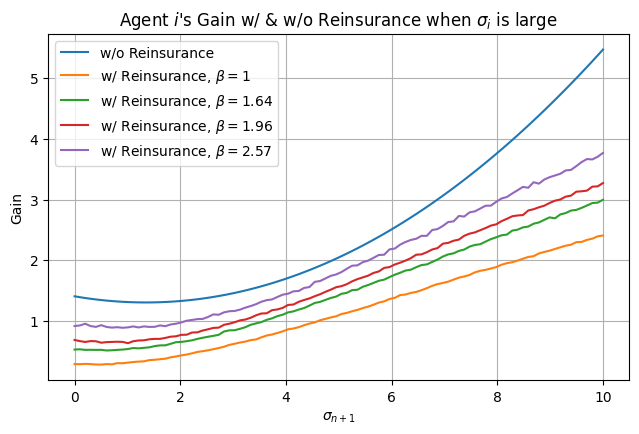

In [ ]:
#Plot all together
plt.figure(figsize=(7.5, 4.5))

# Plot, w/o R function
plt.plot(As3,y1,label=r'w/o Reinsurance')

# Create a plot, w/ R Monte Carlo
for i in range(len(Abeta)):
    plt.plot(As3,result_hetero_beta[i], label=r'w/ Reinsurance, $\beta={}$'.format(Abeta[i]))

plt.legend()
plt.xlabel(r'$\sigma_{n+1}$')
plt.ylabel('Gain')
plt.title(r"Agent $i$'s Gain w/ & w/o Reinsurance when $\sigma_i$ is large")
plt.grid(True)
# plt.savefig('20231222_equi_strong_wwoR_compare_homo_r.jpg')
plt.show()
# files.download('20231222_equi_strong_wwoR_compare_homo_r.jpg')

Simulation, heterogeneous risk case, two agents, your risk big

Parameters

In [ ]:
#Parameters
Nsamplesize = 1000
Amean = np.array([0,0,0],dtype=float)
Avar = np.array([1,15],dtype=float)
Adeltas = np.array([1,1,1],dtype=float)
Ncorr = 0.2
Nexist = 2
As3=np.linspace(0,10,100)
Abeta=[1,1.64,1.96, 2.57]
Ncorr = 0.2
trial = 1000

Without Reinsurance

In [ ]:
# condition
x = np.linspace(0, 10, 100)
y1 = wo_formula(x, Avar, Ncorr, Adeltas, 2, 0)/18

With Reinsurance

In [ ]:
result_hetero_beta_your = []

for beta in Abeta:
    result_temp = np.zeros(len(As3), dtype=float)

    for i in range(trial):
        result_temp2 = []

        for s3 in As3:

            # samples
            Asample_XiSn, Asample_XiSn1, k2, k3 = get_sample_wR(s3, Amean, Avar, beta, Ncorr, Nsamplesize)

            # Utility with insurance
            U_n=wi_monte(Asample_XiSn,k2,2)
            U_n1=wi_monte(Asample_XiSn1,k3,3)
            result_temp2.append(U_n-U_n1)

        result_temp += np.array(result_temp2, dtype=float)/trial
    result_hetero_beta_your.append(result_temp)

Plotting (Figure 3.d.)

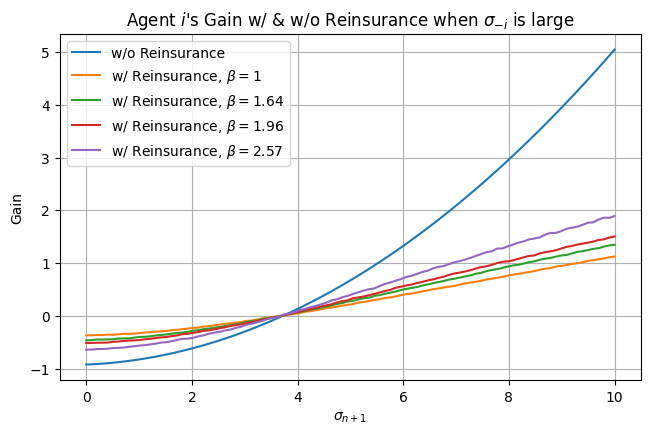

In [ ]:
#Plot all together
plt.figure(figsize=(7.5, 4.5))

# Plot, w/o R function
plt.plot(As3,y1,label=r'w/o Reinsurance')

# Create a plot, w/ R Monte Carlo
for i in range(len(Abeta)):
    plt.plot(As3,result_hetero_beta_your[i], label=r'w/ Reinsurance, $\beta={}$'.format(Abeta[i]))

plt.legend()
plt.xlabel(r'$\sigma_{n+1}$')
plt.ylabel('Gain')
plt.title(r"Agent $i$'s Gain w/ & w/o Reinsurance when $\sigma_{-i}$ is large")
plt.grid(True)
# plt.savefig('20231222_equi_strong_wwoR_compare_homo_r.jpg')
plt.show()
# files.download('20231222_equi_strong_wwoR_compare_homo_r.jpg')

##Figure 4

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import norm
from scipy.stats import multivariate_normal
from google.colab import files
import random

Fair Premium

Without reinsurance

In [ ]:
def function1(sn,d,r,x):
    return sn**2 / d**2 - (sn**2 + x**2 + 2*sn*x*r) / (d + 1)**2

With reinsurance

In [ ]:
def custom_function(sn,d, beta):
    x=sn/d
    term1 = np.log(np.exp((x**2)/2) * norm.cdf(beta - x) + np.exp(beta*x) * (1 - norm.cdf(beta)))
    term2 = x * (norm.pdf(beta) - beta * (1 - norm.cdf(beta)))
    result = term1 + term2
    return result

Parameters

In [ ]:
x_values = np.linspace(0, 10, 100)
sn=13
d=5
rho=0.2
beta=1.96

Results

In [ ]:
y_values_function1 = function1(sn,d,rho,x_values)
y_values_function2 = custom_function(sn, d, beta) - custom_function(np.sqrt(sn**2 + x_values**2 + 2*sn*x_values*rho), d+1, beta)

Plots (Figure 4.a)

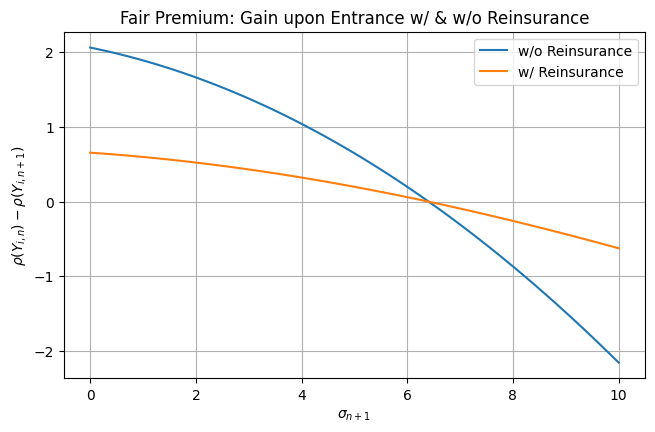

In [ ]:
plt.figure(figsize=(7.5, 4.5))
plt.plot(x_values, y_values_function1, label='w/o Reinsurance')
plt.plot(x_values, y_values_function2, label='w/ Reinsurance')
plt.xlabel(r'$\sigma_{n+1}$')
plt.ylabel(r'$\rho(Y_{i,n})-\rho(Y_{i,n+1})$')
plt.title('Fair Premium: Gain upon Entrance w/ & w/o Reinsurance')
plt.legend()
plt.grid(True)
# plt.savefig('20240105_fair_AR_gain.jpg')
plt.show()
# files.download('20240105_fair_AR_gain.jpg')

Equilibrium pricing

Sampling for monte carlo when there is reinsurance

In [ ]:
def get_sample_wR(s3,mean,var,beta, rho,size_sample):

    s1=np.sqrt(var[0])
    s2=np.sqrt(var[1])
    u1=mean[0]
    u2=mean[1]
    u3=mean[2]

    k2=u1+u2+beta*np.sqrt(s1**2+s2**2+2*rho*(s1*s2))
    k3=u1+u2+u3+beta*np.sqrt(s1**2+s2**2+s3**2+2*rho*(s1*s2+s2*s3+s3*s1))

    # Parameters for the bivariate normal distribution with n, X1 and Sn
    mean_vector = np.array([u1, u1+u2])
    covariance_matrix = np.array([[s1**2, s1**2+rho*s1*s2], [s1**2+rho*s1*s2, s1**2+s2**2+2*rho*s1*s2]])

    # Generate random samples from the normal distribution with n, X1 and Sn
    samples_n = multivariate_normal.rvs(mean=mean_vector, cov=covariance_matrix, size=size_sample)

    # Parameters for the bivariate normal distribution with n+1, X1 and Sn
    mean_vector1 = np.array([u1, u1+u2+u3])
    covariance_matrix1 = np.array([[s1**2, s1**2+rho*s1*s2+rho*s1*s3], [s1**2+rho*s1*s2+rho*s1*s3, s1**2+s2**2+s3**2+2*rho*(s1*s2+s2*s3+s3*s1)]])

    # Generate random samples from the normal distribution with n+1, X1 and Sn
    samples_n1 = multivariate_normal.rvs(mean=mean_vector1, cov=covariance_matrix1, size=size_sample)

    return samples_n, samples_n1, k2, k3

Without Reinsurance

In [ ]:
# Define a function
def wo_formula(x, var, cor, delt, num, index):
    # Calculate the covariance matrix with fixed pairwise correlations of (cor)
    correlation = cor
    cov = np.diag(var)
    for i in range(num):
        for j in range(i + 1, num):
            cov[i, j] = cov[j, i] = correlation * np.sqrt(var[i] * var[j])

    #Parameters
    sum_sd = np.sum(np.sqrt(var))  #\Sigma_n
    total_var = np.sum(cov)  #s_n^2
    lam_ni = delt[index]/np.sum(delt[:num]) #lambda_n,i
    lam_n1i = delt[index]/np.sum(delt) #lambda_n+1,i
    func=x**2+2*cor*(sum_sd-np.sqrt(var[index])/lam_n1i)*x+2*(lam_ni/(lam_n1i**2)-1/lam_n1i)*(var[index]+cor*np.sqrt(var[index])*(sum_sd-np.sqrt(var[index])))-((lam_ni**2)/(lam_n1i**2)-1)*total_var

    return func

With reinsurance

In [ ]:
def wi_monte(data, K, n):
    x_values = data[:, 0]
    y_values = data[:, 1]
    y_values_trun = np.array([min(element, K) for element in y_values])

    fn1= np.log(np.mean(np.exp(y_values_trun/n)))
    fn2= np.mean(x_values * np.exp(y_values_trun / n))/np.mean(np.exp(y_values_trun/n))
    fn3= np.mean(y_values * np.exp(y_values_trun / n))/np.mean(np.exp(y_values_trun/n))*(1/n)
    fn4= np.mean([max(element-K,0) for element in y_values])*(1/n)

    result=fn1+fn2-fn3+fn4
    return result

W/O estimate for strong consensus

In [ ]:
#############   w/o R Function #####################
# Set random seeds for reproducibility
# np.random.seed(0)

# Parameters are given by sn=13 d=5 dn1=5+1 rho(sn,sigman+1)=0.2, beta=1.96

# Define the number of agents
var = np.array([1,20],dtype=float)
corr = 0.2
deltas = np.array([5,20,10],dtype=float)

# condition
x = np.linspace(0, 10, 100)
y1 = wo_formula(x, var, corr, deltas, 2, 0)

W/ estimate for strong consensus

In [ ]:
#############   w/R Monte #####################

#Parameters
Nsamplesize = 1000
Amean = np.array([0,0,0],dtype=float)
Avar = np.array([1,20],dtype=float)
Adeltas = np.array([5,20,10],dtype=float)
Ncorr = 0.2
Nexist = 2
As3=np.linspace(0,10,100)
Nbeta = 1.96
trial = 1000

In [ ]:
result = np.zeros(len(As3), dtype=float)
for i in range(trial):
    result_temp=[]
    for s3 in As3:
        # samples
        Asample_XiSn, Asample_XiSn1, k2, k3 = get_sample_wR(s3, Amean, Avar, Nbeta, Ncorr, Nsamplesize)

        # Utility with insurance
        U_n=wi_monte(Asample_XiSn,k2,2)
        U_n1=wi_monte(Asample_XiSn1,k3,3)
        result_temp.append(U_n-U_n1)
    result += np.array(result_temp, dtype=float)/trial

Plotting (Figure 4.b)

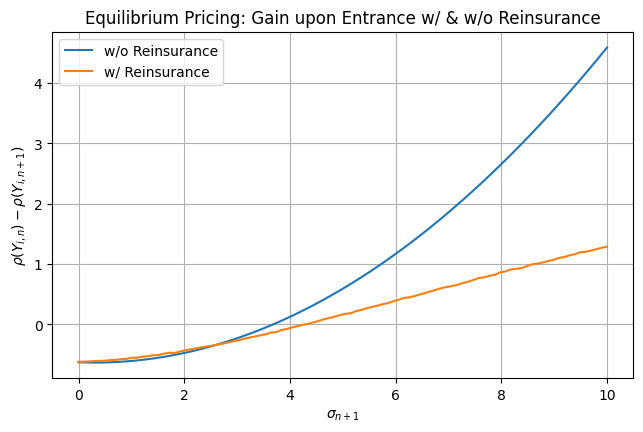

In [ ]:
#Plot all together

plt.figure(figsize=(7.5, 4.5))

# Plot, w/o R function
plt.plot(x,y1/18,label=r'w/o Reinsurance')

# Create a plot, w/ R Monte Carlo
plt.plot(As3,result, label=r'w/ Reinsurance')

plt.legend()
plt.xlabel(r'$\sigma_{n+1}$')
plt.ylabel(r'$\rho(Y_{i,n})-\rho(Y_{i,n+1})$')
plt.title('Equilibrium Pricing: Gain upon Entrance w/ & w/o Reinsurance')
plt.grid(True)
# plt.savefig('20240105_wR_AR_change.jpg')
plt.show()
# files.download('20240105_wR_AR_change.jpg')

#E-Companion

##Figure 2

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from tqdm import tqdm
from scipy.linalg import cholesky

Load Data

In [ ]:
df = pd.read_csv('/path/CCRIF_TC.csv') # PLease put your desired path
df2 = pd.read_csv('/path/CCRIF_TC_Info.csv') # PLease put your desired path
df2["GDP"] = df2["GDP"] / 1e5
# df2["GDP"] = df2["GDP"].astype(int)
df2["GDP"] = df2["GDP"].astype(float).round(1)

Group by  Year

In [ ]:
# Group by 'Year' and sum payouts
grouped = df.groupby('Year')['Payout'].sum()

# Define the range of years from 2008 to 2024
years = list(range(2008, 2025))

# Reindex to include all years and fill missing years with 0
df_yr = grouped.reindex(years, fill_value=0).reset_index()

# Rename columns for clarity
df_yr.columns = ['Year', 'Payout']
# Convert Payout to US Million Dollars
df_yr["Payout_Million"] = df_yr["Payout"] / 1e5

MLE & k value

In [ ]:
# Calculate Maximum Likelihood Estimate for mean
mean_mle = np.mean(df_yr['Payout_Million'])

# Calculate Maximum Likelihood Estimate for variance
variance_mle = np.mean((df_yr['Payout_Million'] - mean_mle) ** 2)
print(f"MLE Mean: {mean_mle:.4f}")
print(f"MLE SD: {variance_mle:.4f}")

MLE Mean: 159.5598
MLE SD: 56598.2819


In [ ]:
# Constants
rho = 0.3
m_n = mean_mle
s_n_squared = variance_mle  # Target adjusted variance

# Compute \hat{\sigma}_j^2 for each country
df2["Sigma_j_squared"] = (
    (df2["Occurrence_Probability"]) * (1-df2["Occurrence_Probability"])
    * (df2["GDP"]**2)
)

# Sum of \hat{\sigma}_j^2
sigma_squared_sum = df2["Sigma_j_squared"].sum()

# Pairwise cross terms for 2\rho \sum_{i \neq j} \hat{\sigma}_i \hat{\sigma}_j
pairwise_sum = rho * sum(
    np.sqrt(df2["Sigma_j_squared"].iloc[i]) * np.sqrt(df2["Sigma_j_squared"].iloc[j])
    for i in range(len(df2))
    for j in range(len(df2))
    if i != j
)

# Solve for k^2
k_squared = s_n_squared / (sigma_squared_sum + 2 * pairwise_sum)

# Solve for k
k = np.sqrt(k_squared)

print(f"Value of k: {k}")

Value of k: 0.00038635994594979177


Compute Adjusted Mean and Adjusted Variance

In [ ]:
df2["Adjusted_Mean"] = (
    k
    * df2["Occurrence_Probability"]
    * df2["GDP"]
)

df2["Adjusted_Var"] = (
    k**2
    * (df2["Occurrence_Probability"])**2
    * (df2["GDP"])**2
)

Data for mean and variance

In [ ]:
data = df2[['Country','Adjusted_Mean','Adjusted_Var']]
data

,Country,Adjusted_Mean,Adjusted_Var
0,Anguilla,0.127148,0.016166
1,Antigua & Barbuda,0.285204,0.081341
2,Barbados,2.693280,7.253757
3,Belize,0.691233,0.477803
4,British Virgin Islands,0.033498,0.001122
5,Cayman Islands,0.491028,0.241109
6,Dominica,0.091883,0.008443
7,Grenada,0.463632,0.214955
8,Guatemala,17.393925,302.548619
9,Haiti,3.022037,9.132709


Existing Members

In [ ]:
# List of countries for which we want to calculate the variance
countries = [
    'Anguilla', 'Antigua & Barbuda', 'The Bahamas', 'Barbados', 'Belize', 'Bermuda',
    'Cayman Islands', 'Dominica', 'Grenada', 'Haiti', 'Jamaica', 'St. Kitts & Nevis',
    'Saint Lucia', 'St. Vincent & the Grenadines', 'The Republic of Trinidad and Tobago',
    'Turks & Caicos Islands'
]

# Filter the dataframe to include only the specified countries
df_ex = data[data['Country'].isin(countries)]
df_ex.reset_index(drop=True, inplace=True)
df_ex

,Country,Adjusted_Mean,Adjusted_Var
0,Anguilla,0.127148,0.016166
1,Antigua & Barbuda,0.285204,0.081341
2,Barbados,2.693280,7.253757
3,Belize,0.691233,0.477803
4,Cayman Islands,0.491028,0.241109
5,Dominica,0.091883,0.008443
6,Grenada,0.463632,0.214955
7,Haiti,3.022037,9.132709
8,Jamaica,6.832249,46.679624
9,Saint Lucia,0.531069,0.282035


Candidates

In [ ]:
df_can = data[~data['Country'].isin(countries)]
df_can.reset_index(drop=True, inplace=True)
df_can

,Country,Adjusted_Mean,Adjusted_Var
0,British Virgin Islands,0.033498,0.001122
1,Guatemala,17.393925,302.548619
2,Nicaragua,5.036729,25.368637
3,Panama,5.857217,34.306988


Fairness Principle w/o Reinsurance

In [ ]:
# Compute variance of the sum for cluster (0-29)
def cluster_variance(variances, rho):
    total_variance = sum(variances)
    pairwise_covariance = 2 * rho * sum(
        np.sqrt(variances[i] * variances[j]) for i in range(len(variances)) for j in range(i + 1, len(variances))
    )
    return total_variance + pairwise_covariance

In [ ]:
# Select variance levels for the age group cluster 0-29
variances = df_ex['Adjusted_Var'].values
rho = 0.3
n = len(variances)  # Number of groups in the cluster
expanded_variances = np.linspace(0, 10, 100)  # Variance range for new group

Baseline

In [ ]:
# Calculate standard deviation / n for different rho levels
baseline = np.sqrt(cluster_variance(variances, rho)) / n
baseline

0.993278353997065

Expanded

In [ ]:
expanded = []
for new_variance in expanded_variances:
    extended_variances = list(variances) + [new_variance]
    var_sum = cluster_variance(extended_variances, rho)
    std_dev = np.sqrt(var_sum) / (n + 1)
    expanded.append(std_dev)

Plot (Figure 2.a)

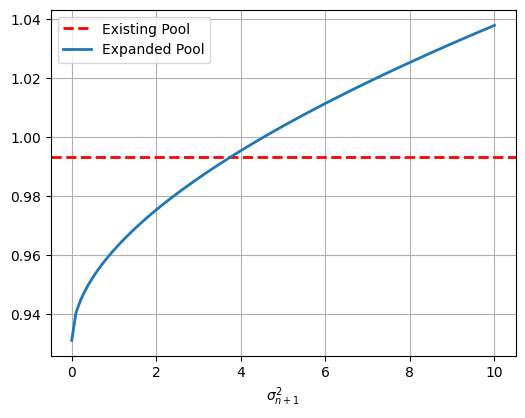

In [ ]:
# Plot
plt.figure(figsize=(6, 4.5))

# Plot baseline
plt.axhline(y=baseline, linewidth=2, label='Existing Pool', color='red', linestyle='--')

# Plot expanded standard deviations
plt.plot(expanded_variances, expanded, label='Expanded Pool',  linewidth=2)

# Add labels, title, and legend
# plt.title('Effect of New Variance on Standard Deviation / n')
plt.xlabel(r'$\sigma_{n+1}^2$')
# plt.ylabel(r'Entropic Risk measure')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

Fairness Principle w/ Reinsurance

In [ ]:
# Vectorized entropic risk measure function
def entropic_risk_measure(x, beta):
    phi = norm.pdf(beta)
    Phi = norm.cdf(beta)
    term1 = np.log(
        np.exp(x**2 / 2) * norm.cdf(beta - x) + np.exp(beta * x) * (1 - Phi)
    )
    term2 = x * (phi - beta * (1 - Phi))
    return term1 + term2

In [ ]:
# Select variance levels for the age group cluster 0-29
variances = df_ex['Adjusted_Var'].values
rho = 0.3
n = len(variances)  # Number of groups in the cluster
expanded_variances = np.linspace(0, 10, 100)  # Variance range for new group
beta = 1.64

In [ ]:
baseline = np.sqrt(cluster_variance(variances, rho)) / n
baseline_risk_measure = entropic_risk_measure(baseline, beta)

In [ ]:
expanded_risk_measure = []
for new_variance in expanded_variances:
    extended_variances = list(variances) + [new_variance]
    dev_tol = np.sqrt(cluster_variance(extended_variances, rho)) / (n+1)
    expanded_risk_measure.append(entropic_risk_measure(dev_tol, beta))

Plot (Figure 2.b)

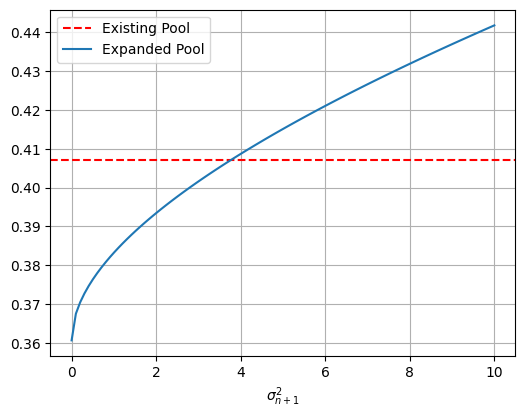

In [ ]:
# Plotting
plt.figure(figsize=(6, 4.5))
plt.axhline(y=baseline_risk_measure, color="r", linestyle="--", label="Existing Pool")
plt.plot(expanded_variances, expanded_risk_measure, label="Expanded Pool")
plt.xlabel(r"$\sigma_{n+1}^2$")
# plt.ylabel(r"$l\left(\frac{s_{n+1}}{\Delta_{n+1}},\beta\right)$,$l\left(\frac{s_n}{\Delta_n},\beta\right)$")
# plt.title("Entropic Risk Measure: Original vs Extended")
plt.legend()
plt.grid(True)
plt.show()

##Figure 3

Equilibrium Principle w/o Reinsurance

In [ ]:
# Define a function
def wo_formula(x, var, cor, delt, num, index):
    # Calculate the covariance matrix with fixed pairwise correlations of (cor)
    correlation = cor
    cov = np.diag(var)
    for i in range(num):
        for j in range(i + 1, num):
            cov[i, j] = cov[j, i] = correlation * np.sqrt(var[i] * var[j])

    #Parameters
    sum_sd = np.sum(np.sqrt(var))  #Sigma_n
    total_var = np.sum(cov)  #s_n^2
    lam_ni = delt[index]/np.sum(delt[:num]) #lambda_n,i
    lam_n1i = delt[index]/np.sum(delt) #lambda_n+1,i
    func=x**2+2*cor*(sum_sd-np.sqrt(var[index])/lam_n1i)*x+2*(lam_ni/(lam_n1i**2)-1/lam_n1i)*(var[index]+cor*np.sqrt(var[index])*(sum_sd-np.sqrt(var[index])))-((lam_ni**2)/(lam_n1i**2)-1)*total_var

    return func

In [ ]:
# Select variance levels for the age group cluster 0-29
variances = df_ex['Adjusted_Var'].values
n = len(variances)  # Number of groups in the cluster
rho = 0.3
expanded_variances = np.linspace(0, 4, 100)  # Variance range for new group
deltas = np.ones(len(variances) + 1)
var_range = np.linspace(0,100, 100)

In [ ]:
# Plot graphs for each index in sig_list
each_country = []  # Initialize an empty list to store the results for plotting
for i in range(len(variances)):
    temp = []
    for var in var_range :
        temp.append(wo_formula(var, variances, rho, deltas, len(variances), i))
    each_country.append(temp)  # Append each result to y_values

Plot (Figure 3.a)

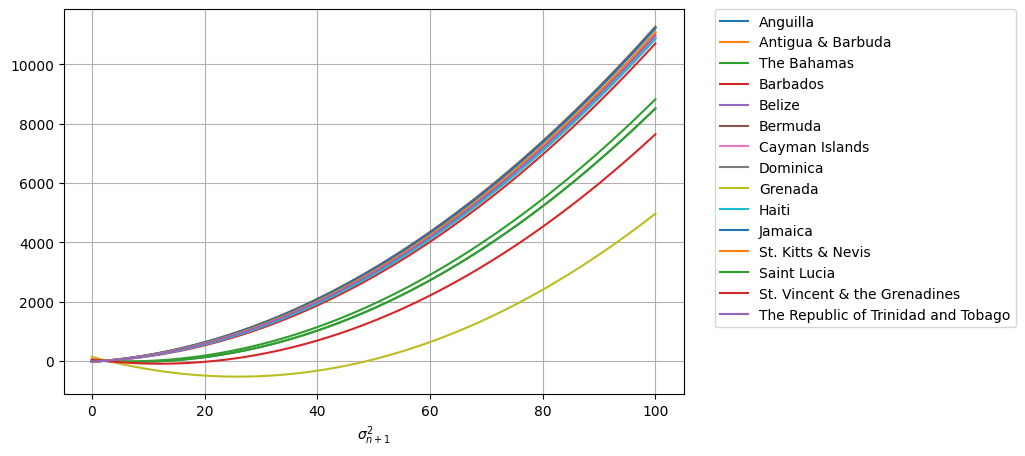

In [ ]:
plt.figure(figsize=(8, 5))
# Plot each graph
for i in range(len(variances)):
    plt.plot(var_range , each_country[i], label=f'{countries[i]}')

# Add labels and legend
plt.xlabel(r'$\sigma_{n+1}^2$')
# plt.ylabel(r'$f_{i}(\sigma_{n+1})$')
plt.ylim(-1000, 2000)
# Place legend to the right of the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)

# Show the plot
plt.show()

Equilibrium Principle w/ Reinsurance

In [ ]:
def transform_standard_normal(std_normal_samples, means, variances, correlation, cholesky_matrix, i):
    # Transform standard normal samples into correlated samples with given means and variances
    transformed_samples = std_normal_samples @ cholesky_matrix.T + means

    # Get the sum along each row
    sum_of_samples = transformed_samples.sum(axis=1)

    # Extract the first transformed sample
    ith_distribution = transformed_samples[:, i]

    return sum_of_samples, ith_distribution

# Compute entropic risk measure
def entropic_risk_measure_extended(samples_S, samples_X, delta, delta_n, beta):
    # Compute K values for the truncated samples
    mean_Sn = np.mean(samples_S)
    var_Sn = np.var(samples_S)
    Kn = mean_Sn + beta * var_Sn
    truncated = np.minimum(samples_S, Kn)

    # Equilibrium expectations
    weights = np.exp(truncated / delta_n) / np.mean(np.exp(truncated / delta_n))

    # Final entropic risk measure calculation
    risk_measure = (
        delta * np.log(np.mean(np.exp(truncated / delta_n))) +
        delta / delta_n * np.mean(np.maximum(samples_S - Kn, 0)) +
        np.mean(weights * (samples_X - delta / delta_n * samples_S))
    )
    return risk_measure

In [ ]:
# Parameters
means = df_ex['Adjusted_Mean'].values
variances = df_ex['Adjusted_Var'].values
beta = 1.64
correlation = 0.3
simulation_num = 5000  # Number of simulations
x_values = np.linspace(0.01, 400, 100)  # Variance extension values
num_samples = 500
delta = 1
delta_n = len(means)  # Example Delta_n
delta_n1 = len(means) + 1  # Example Delta_n+1
deltas = np.ones(len(variances) + 1)

In [ ]:
# Precompute Cholesky decomposition of the covariance matrix
std_devs = np.sqrt(variances)
cov_matrix = np.full((len(means), len(means)), correlation)
np.fill_diagonal(cov_matrix, 1)  # Set diagonal to 1
cov_matrix = np.outer(std_devs, std_devs) * cov_matrix
cholesky_matrix = cholesky(cov_matrix, lower=True)

# Baseline entropic risk measure
original_risks = []
for i in range(len(variances)):
    temp = []
    for _ in tqdm(range(simulation_num), desc=f"Existing Pool: {countries[i]}"):
        std_normal_samples = np.random.normal(0, 1, (num_samples, len(means)))  # Generate standard normal samples
        baseline_samples_Sn, baseline_samples_X = transform_standard_normal(std_normal_samples, means, variances, rho, cholesky_matrix, i)
        entropic_risks = entropic_risk_measure_extended(baseline_samples_Sn, baseline_samples_X, 1, len(variances), beta)
        temp.append(entropic_risks)
    original_risks.append(np.mean(temp))

Existing Pool: St. Vincent & the Grenadines: 100%|██████████| 5000/5000 [00:02<00:00, 1997.74it/s]
Existing Pool: The Republic of Trinidad and Tobago: 100%|██████████| 5000/5000 [00:03<00:00, 1631.11it/s]


In [ ]:
# Simulation for extended risk measure
extended_means = np.append(means, np.median(df2['Adjusted_Mean']))
extended_results_each_country = []

for i in range(len(variances)):
    temp = []
    for sim in tqdm(range(simulation_num), desc=f"Expanded Pool: {countries[i]}"):
        sim_results = []
        std_normal_samples = np.random.normal(0, 1, (num_samples, len(extended_means)))
        for x in x_values:
            extended_variances = np.append(variances, x)
            std_devs = np.sqrt(extended_variances)
            cov_matrix = np.full((len(extended_means), len(extended_means)), rho)
            np.fill_diagonal(cov_matrix, 1)  # Set diagonal to 1
            cov_matrix = np.outer(std_devs, std_devs) * cov_matrix
            cholesky_matrix = cholesky(cov_matrix, lower=True)
            extended_samples_Sn, extended_samples_X = transform_standard_normal(std_normal_samples, extended_means, extended_variances, rho, cholesky_matrix, i)
            risk_measure = entropic_risk_measure_extended(extended_samples_Sn, extended_samples_X, 1, len(extended_variances), beta)
            sim_results.append(risk_measure)
        temp.append(sim_results)
    final_results = np.mean(temp, axis=0)
    extended_results_each_country.append(original_risks[i] - final_results)

Expanded Pool: St. Vincent & the Grenadines: 100%|██████████| 5000/5000 [02:31<00:00, 32.99it/s]
Expanded Pool: The Republic of Trinidad and Tobago: 100%|██████████| 5000/5000 [02:32<00:00, 32.83it/s]


Plot (Figure 3.b)

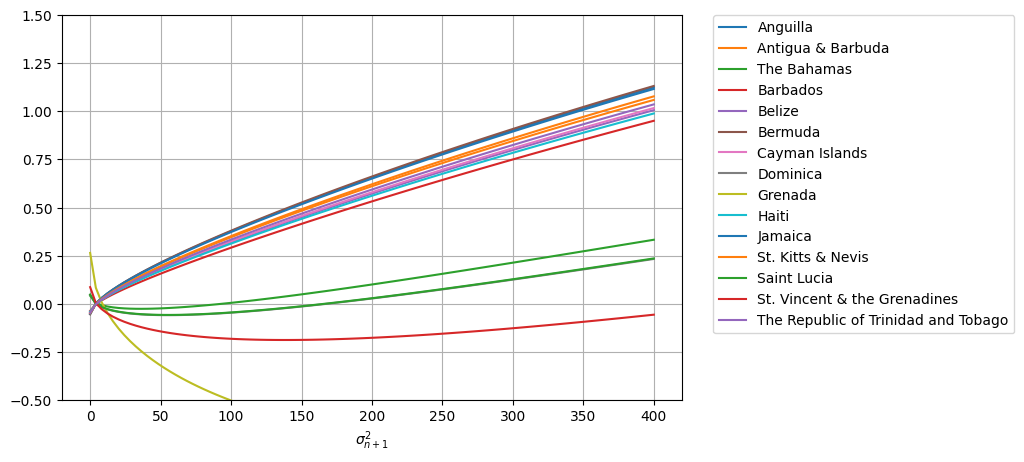

In [ ]:
plt.figure(figsize=(8, 5))
# Plot each graph
for i in range(len(variances)):
    plt.plot(x_values, extended_results_each_country[i], label=f'{countries[i]}')

# Add labels and legend
plt.xlabel(r'$\sigma_{n+1}^2$')
# plt.ylabel(r'$f_{i}(\sigma_{n+1})$')

# Place legend to the right of the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
plt.ylim(-0.5, 1.5)

# Show the plot
plt.show()

##Figure 4

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.linalg import cholesky
from scipy.stats import norm

In [ ]:
data = pd.read_excel('/path/Health_data.xlsx') #Please insert the desired path

Fairness Principle w/o Reinsurance

In [ ]:
# Select variance levels for the age group cluster 0-29
region_cluster = ['Beijing', 'Tianjin', 'Shenyang', 'Dalian']
means = data.loc[data['Region'].isin(region_cluster), 'Mean_Compensation'].values
variances = data.loc[data['Region'].isin(region_cluster), 'Variance_Compensation'].values
rho = 0.3  # Correlation levels
n = len(variances)  # Number of groups in the cluster
candidate_variance = np.linspace(0.01, 50, 100)  # Variance range for new group

In [ ]:
# Compute variance of the sum for cluster (0-29)
def cluster_variance(variances, rho):
    total_variance = sum(variances)
    pairwise_covariance = 2 * rho * sum(
        np.sqrt(variances[i] * variances[j]) for i in range(len(variances)) for j in range(i + 1, len(variances))
    )
    return total_variance + pairwise_covariance

Baseline

In [ ]:
# Calculate standard deviation / n for different rho levels
baseline = np.sqrt(cluster_variance(variances, rho)) / n
print(baseline)

2.8974639993085436


Expanded

In [ ]:
expanded = []
rho=0.3
for new_variance in candidate_variance:
    extended_variances = list(variances) + [new_variance]
    var_sum = cluster_variance(extended_variances, rho)
    std_dev = np.sqrt(var_sum) / (n + 1)
    expanded.append(std_dev)

Plot (Figure 4.a)

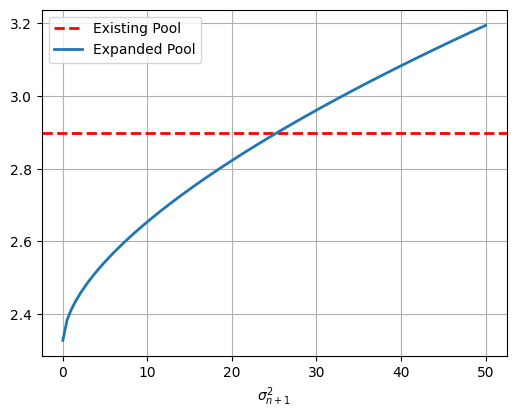

In [ ]:
# Plot
plt.figure(figsize=(6, 4.5))

# Plot baseline
plt.axhline(y=baseline, linewidth=2, label='Existing Pool', color='red', linestyle='--')

# Plot expanded standard deviations
plt.plot(candidate_variance, expanded, label='Expanded Pool',  linewidth=2)

# Add labels, title, and legend
plt.xlabel(r'$\sigma_{n+1}^2$')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

Fairness Principle w Reinsurance

In [ ]:
# Optimized transform_standard_normal function
def transform_standard_normal(std_normal_samples, means, variances, correlation, cholesky_matrix):
    # Transform standard normal samples into correlated samples with given means and variances
    transformed_samples = std_normal_samples @ cholesky_matrix.T + means
    return transformed_samples.sum(axis=1)

# Vectorized entropic risk measure function
def entropic_risk_measure(x_array, beta):
    phi = norm.pdf(beta)
    Phi = norm.cdf(beta)
    term1 = np.log(
        np.exp(x_array**2 / 2) * norm.cdf(beta - x_array) + np.exp(beta * x_array) * (1 - norm.cdf(beta))
    )
    term2 = x_array * (phi - beta * (1 - Phi))
    return term1 + term2

In [ ]:
# Parameters
beta = 1.64
simulation_num = 3000
num_samples = 1000

In [ ]:
# Precompute Cholesky decomposition of the covariance matrix
std_devs = np.sqrt(variances)
cov_matrix = np.full((len(means), len(means)), rho)
np.fill_diagonal(cov_matrix, 1)  # Set diagonal to 1
cov_matrix = np.outer(std_devs, std_devs) * cov_matrix
cholesky_matrix = cholesky(cov_matrix, lower=True)

# Baseline entropic risk measure
original_risks = []
for _ in tqdm(range(simulation_num), desc="Simulating Original Risks"):
    std_normal_samples = np.random.normal(0, 1, (num_samples, len(means)))  # Generate standard normal samples
    baseline_samples = transform_standard_normal(std_normal_samples, means, variances, rho, cholesky_matrix)
    s_n_div_n = baseline_samples / len(means)
    entropic_risks = entropic_risk_measure(s_n_div_n, beta)
    original_risks.append(np.mean(entropic_risks))

baseline_risk_measure = np.nanmean(original_risks)

Simulating Original Risks: 100%|██████████| 3000/3000 [00:03<00:00, 848.45it/s] 


In [ ]:
# Extended entropic risk measure
extended_means = np.append(means, np.median(means))  # Add a fixed value for extended mean
extended_results = []

for sim in tqdm(range(simulation_num), desc="Simulating Extended Risks"):
    std_normal_samples = np.random.normal(0, 1, (num_samples, len(extended_means)))  # Adjust for extended dimension
    sim_results = []
    for x in candidate_variance:
        extended_variances = np.append(variances, x)
        std_devs_extended = np.sqrt(extended_variances)
        cov_matrix_extended = np.full((len(extended_means), len(extended_means)), rho)
        np.fill_diagonal(cov_matrix_extended, 1)
        cov_matrix_extended = np.outer(std_devs_extended, std_devs_extended) * cov_matrix_extended
        cholesky_matrix_extended = cholesky(cov_matrix_extended, lower=True)
        extended_samples = transform_standard_normal(
            std_normal_samples, extended_means, extended_variances, rho, cholesky_matrix_extended
        )
        s_n1_div_n1 = extended_samples / len(extended_means)
        entropic_risk = np.mean(entropic_risk_measure(s_n1_div_n1, beta))
        sim_results.append(entropic_risk)
    extended_results.append(sim_results)

# Aggregate results by averaging over simulationss
final_results = np.mean(extended_results, axis=0)

Simulating Extended Risks: 100%|██████████| 3000/3000 [04:33<00:00, 10.96it/s]


Plot (Figure 4.b)

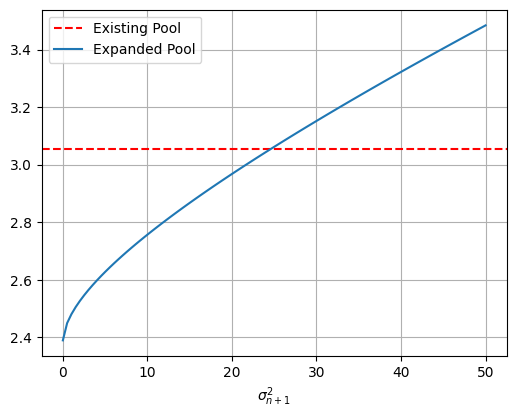

In [ ]:
# Plotting
plt.figure(figsize=(6, 4.5))
plt.axhline(y=baseline_risk_measure, color="r", linestyle="--", label="Existing Pool")
plt.plot(candidate_variance, final_results, label="Expanded Pool")
plt.xlabel(r"$\sigma_{n+1}^2$")
plt.legend()
plt.grid(True)
plt.show()

Equilibrium Principle w/o Reinsurance

In [ ]:
# Define a function
def wo_formula(x, var, cor, delt, num, index):
    # Calculate the covariance matrix with fixed pairwise correlations of (cor)
    correlation = cor
    cov = np.diag(var)
    for i in range(num):
        for j in range(i + 1, num):
            cov[i, j] = cov[j, i] = correlation * np.sqrt(var[i] * var[j])

    #Parameters
    sum_sd = np.sum(np.sqrt(var))  #\Sigma_n
    total_var = np.sum(cov)  #s_n^2
    lam_ni = delt[index]/np.sum(delt[:num]) #lambda_n,i
    lam_n1i = delt[index]/np.sum(delt) #lambda_n+1,i
    func=x**2+2*cor*(sum_sd-np.sqrt(var[index])/lam_n1i)*x+2*(lam_ni/(lam_n1i**2)-1/lam_n1i)*(var[index]+cor*np.sqrt(var[index])*(sum_sd-np.sqrt(var[index])))-((lam_ni**2)/(lam_n1i**2)-1)*total_var

    return func

In [ ]:
# Parameters
deltas = np.ones(len(variances) + 1)
sigma_range = np.linspace(0,4, 100)

In [ ]:
# Plot graphs for each index in sig_list
each_country = []  # Initialize an empty list to store the results for plotting
for i in range(len(variances)):
    temp = []
    for var in sigma_range:
        temp.append(wo_formula(var, variances, rho, deltas, len(variances), i))
    each_country.append(temp)  # Append each result to y_values

Plot (Figure 4.c)

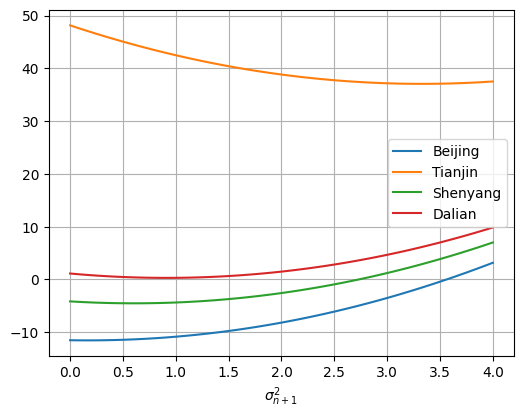

In [ ]:
plt.figure(figsize=(6, 4.5))
# Plot each graph
for i in range(len(variances)):
    plt.plot(sigma_range, each_country[i], label=f"{region_cluster[i]}")

# Add labels and legend
plt.xlabel(r'$\sigma_{n+1}^2$')
# plt.ylabel(r'$f_{i}(\sigma_{n+1})$')
plt.legend()
plt.grid(True)
# plt.title('Graphs for wo_formula')
plt.show()


Equilibrium Principle w/ Reinsurance

In [ ]:
def transform_standard_normal(std_normal_samples, means, variances, correlation, cholesky_matrix, i):
    # Transform standard normal samples into correlated samples with given means and variances
    transformed_samples = std_normal_samples @ cholesky_matrix.T + means

    # Get the sum along each row
    sum_of_samples = transformed_samples.sum(axis=1)

    # Extract the first transformed sample
    first_distribution = transformed_samples[:, i]

    return sum_of_samples, first_distribution

# Compute entropic risk measure
def entropic_risk_measure_extended(samples_S, samples_X, delta, delta_n, beta):
    # Compute K values for the truncated samples
    mean_Sn = np.mean(samples_S)
    var_Sn = np.var(samples_S)
    Kn = mean_Sn + beta * var_Sn
    truncated = np.minimum(samples_S, Kn)

    # Equilibrium expectations
    weights = np.exp(truncated / delta_n) / np.mean(np.exp(truncated / delta_n))

    # Final entropic risk measure calculation
    risk_measure = (
        delta * np.log(np.mean(np.exp(truncated / delta_n))) +
        delta / delta_n * np.mean(np.maximum(samples_S - Kn, 0)) +
        np.mean(weights * (samples_X - delta / delta_n * samples_S))
    )
    return risk_measure

In [ ]:
# Parameters
beta = 1.64
x_values = np.linspace(0.01, 12, 100)  # Variance extension values
deltas = np.ones(len(variances) + 1)
simulation_num = 10000  # Number of simulations
num_samples = 10000

In [ ]:
# Precompute Cholesky decomposition of the covariance matrix
std_devs = np.sqrt(variances)
cov_matrix = np.full((len(means), len(means)), rho)
np.fill_diagonal(cov_matrix, 1)  # Set diagonal to 1
cov_matrix = np.outer(std_devs, std_devs) * cov_matrix
cholesky_matrix = cholesky(cov_matrix, lower=True)

# Baseline entropic risk measure
original_risks = []
for i in range(len(region_cluster)):
    temp = []
    for _ in tqdm(range(simulation_num), desc="Existing Pool"):
        std_normal_samples = np.random.normal(0, 1, (num_samples, len(means)))  # Generate standard normal samples
        baseline_samples_Sn, baseline_samples_X = transform_standard_normal(std_normal_samples, means, variances, rho, cholesky_matrix, i)
        entropic_risks = entropic_risk_measure_extended(baseline_samples_Sn, baseline_samples_X, 1, len(variances), beta)
        temp.append(entropic_risks)
    original_risks.append(np.mean(temp))

Existing Pool: 100%|██████████| 10000/10000 [00:17<00:00, 566.49it/s]


In [ ]:
# Simulation for extended risk measure
extended_means = np.append(means, np.median(means))
extended_results_each_country = []

for i in range(len(region_cluster)):
    temp = []
    for sim in tqdm(range(simulation_num), desc=f"Expanded Pool: {region_cluster[i]}"):
        sim_results = []
        std_normal_samples = np.random.normal(0, 1, (num_samples, len(extended_means)))
        for x in x_values:
            extended_variances = np.append(variances, x)
            std_devs = np.sqrt(extended_variances)
            cov_matrix = np.full((len(extended_means), len(extended_means)), rho)
            np.fill_diagonal(cov_matrix, 1)  # Set diagonal to 1
            cov_matrix = np.outer(std_devs, std_devs) * cov_matrix
            cholesky_matrix = cholesky(cov_matrix, lower=True)
            extended_samples_Sn, extended_samples_X = transform_standard_normal(std_normal_samples, extended_means, extended_variances, rho, cholesky_matrix, i)
            risk_measure = entropic_risk_measure_extended(extended_samples_Sn, extended_samples_X, 1, len(extended_variances), beta)
            sim_results.append(risk_measure)
        temp.append(sim_results)
    final_results = np.mean(temp, axis=0)
    extended_results_each_country.append(original_risks[i] - final_results)

Expanded Pool: Dalian: 100%|██████████| 10000/10000 [13:39<00:00, 12.20it/s]


Plot (Figure 4.d.)

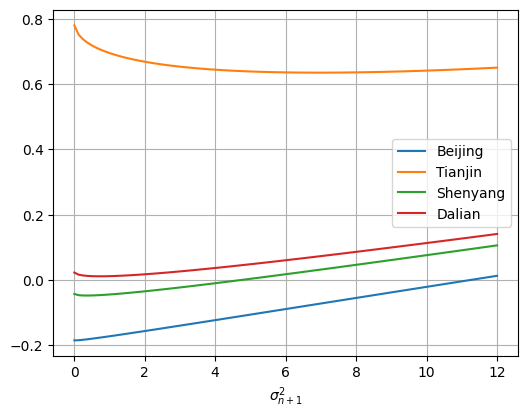

In [ ]:
# Plotting
plt.figure(figsize=(6, 4.5))
# Plot each graph
for i in range(len(variances)):
    plt.plot(x_values, extended_results_each_country[i], label=f"{region_cluster[i]}")

# Add labels and legend
plt.xlabel(r'$\sigma_{n+1}^2$')
# plt.ylabel(r'$f_{i}(\sigma_{n+1})$')
plt.legend()
plt.grid(True)
# plt.title('Graphs for wo_formula')
plt.show()

##Figure 5

Package

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tqdm import tqdm
from scipy.stats import norm

Functions

In [ ]:
def generate_correlated_normal_samples(n, rho, sample_size):

    # Generate correlated normal samples
    cov_matrix = rho * np.ones((n, n)) + (1 - rho) * np.eye(n)
    normal_samples = np.random.multivariate_normal(mean=np.zeros(n), cov=cov_matrix, size=sample_size)

    # Convert normal samples to uniform samples using the CDF of the normal distribution
    uniform_samples = norm.cdf(normal_samples)

    return uniform_samples

In [ ]:
def generate_correlated_exponential_samples(uniform_samples, lambdas):
    """
    Generate correlated exponential samples using a Gaussian copula.
    """
    # Transform uniform samples to exponential samples using the inverse CDF of the exponential distribution
    exponential_samples = [
        -np.log(1 - u) / l for u, l in zip(uniform_samples.T, lambdas)
    ]

    return np.sum(exponential_samples, axis=0), np.array(exponential_samples)

In [ ]:
def Entropic_MZ(S_samples, delta, delta_n, first_samples):
    """
    Calculates the modified entropic risk measure incorporating equilibrium adjustments.
    """
    # Calculate components needed for equilibrium adjustments
    mean_first_sample = np.mean(first_samples)  # Mean of the first exponential distribution samples
    scaled_samples = S_samples / delta_n  # Scaled S_samples for covariance and variance calculations

    # Calculate the entropic risk measure with equilibrium adjustments
    entropic_risk_measure = (
        delta * np.log(np.mean(np.exp(S_samples / delta_n)))
        - delta / delta_n * np.mean(S_samples)
        + mean_first_sample
    )
    return entropic_risk_measure

Parameters

In [ ]:
# Initial parameters
lambdas = [3, 5]  # Lambda values for the initial distributions
delta = 1       # Risk aversion parameter
delta_n = len(lambdas) * delta
rho_values = [0.1, 0.3, 0.7]  # Different correlation coefficients to plot
x_start, x_end = 2, 5
lambda_range = np.linspace(x_start, x_end, 100)
sample_size = 1000  # Number of samples
num_simulations = 3000  # Number of simulations for each lambda value

In [ ]:
# Initialize results storage
entropic_risk_results1 = {rho: {"baseline_avg": None, "entropic_risk_measures": []} for rho in rho_values}

Baseline

In [ ]:
for rho in rho_values:
    # Calculate averaged baseline entropic risk measure with correlated distributions
    baseline_risk_measures = []
    for _ in tqdm(range(num_simulations), desc=f"Baseline Risk Calculation (rho={rho})"):
        uniform_samples = generate_correlated_normal_samples(len(lambdas), rho, sample_size)
        S_samples_baseline, first_samples_baseline = generate_correlated_exponential_samples(uniform_samples, lambdas)
        entropic_risk_baseline = Entropic_MZ(S_samples_baseline, delta, delta_n, first_samples_baseline)
        baseline_risk_measures.append(entropic_risk_baseline)

    # Average the baseline entropic risk measure
    entropic_risk_results1[rho]["baseline_avg"] = np.mean(baseline_risk_measures)

Baseline Risk Calculation (rho=0.7): 100%|██████████| 3000/3000 [00:01<00:00, 1508.62it/s]


Expanded

In [ ]:
# Stage 2: Entropic Risk Measure Calculation for Lambda Range
for rho in rho_values:
    # Initialize storage for all entropic risk measures for this rho
    lambda_risk_measures = {additional_lambda: [] for additional_lambda in lambda_range}

    for _ in tqdm(range(num_simulations), desc=f"Simulation Processing (rho={rho})"):

        # Generate the normal sample inside the simulation loop
        uniform_samples = generate_correlated_normal_samples(len(lambdas) + 1, rho, sample_size)

        for additional_lambda in lambda_range:
            lambdas_with_additional = lambdas + [additional_lambda]
            S_samples, X_samples = generate_correlated_exponential_samples(uniform_samples, lambdas_with_additional)
            entropic_risk = Entropic_MZ(S_samples, delta, delta_n + delta, X_samples)
            lambda_risk_measures[additional_lambda].append(entropic_risk)

    # Compute the mean entropic risk measure for each lambda across all simulations
    averaged_risk_measures = {
        additional_lambda: np.mean(risks) for additional_lambda, risks in lambda_risk_measures.items()
    }

    # Store the averaged risk measures in the results
    entropic_risk_results1[rho]["entropic_risk_measures"] = averaged_risk_measures

Simulation Processing (rho=0.7): 100%|██████████| 3000/3000 [00:43<00:00, 68.54it/s]


Functions

In [ ]:
# Functions
def generate_correlated_normal_samples(n, rho, sample_size):

    # Generate correlated normal samples
    cov_matrix = rho * np.ones((n, n)) + (1 - rho) * np.eye(n)
    normal_samples = np.random.multivariate_normal(mean=np.zeros(n), cov=cov_matrix, size=sample_size)

    # Convert normal samples to uniform samples using the CDF of the normal distribution
    uniform_samples = norm.cdf(normal_samples)

    return uniform_samples

def generate_correlated_exponential_samples(uniform_samples, lambdas):
    """
    Generate correlated exponential samples using a Gaussian copula.
    """
    # Transform uniform samples to exponential samples using the inverse CDF of the exponential distribution
    exponential_samples = [
        -np.log(1 - u) / l for u, l in zip(uniform_samples.T, lambdas)
    ]

    return np.sum(exponential_samples, axis=0), np.array(exponential_samples)

def calculate_p(X_samples, S_samples, delta_n):
    """
    Calculate the vector p in a numerically stable way.
    """
    max_S_delta = np.max(S_samples / delta_n)
    exp_S = np.exp((S_samples / delta_n) - max_S_delta)  # Stabilized exponential
    normalization = np.mean(exp_S)
    weights = exp_S / normalization
    p = np.mean(weights[:, None] * X_samples.T, axis=0)
    return p


def generate_Y(X_samples, p, delta_n):
    """
    Transform X_samples into Y_samples.
    """
    n = len(X_samples)
    A = np.full((n, n), 1 / delta_n)
    Y_samples = np.dot(A, X_samples) - np.dot(A, p[:, None]) + p[:, None]
    return Y_samples

def entropic_risk_individual(Y_samples, delta):
    """
    Calculate the entropic risk measure in a numerically stable way.
    """
    risks = []
    for Y in Y_samples:
        # Subtract max(Y / delta) for numerical stability
        max_Y_delta = np.max(Y / delta)
        stabilized_exp = np.exp((Y / delta) - max_Y_delta)
        stabilized_mean_exp = np.mean(stabilized_exp)
        risk = delta * (np.log(stabilized_mean_exp) + max_Y_delta)
        risks.append(risk)
    return np.array(risks)

In [ ]:
# Parameters
lambdas = [10, 15]  # Lambda values for the initial distributions
delta = 1         # Risk aversion parameter
delta_n = len(lambdas) * delta
sample_size = 1000  # Number of samples
num_simulations = 3000  # Number of simulations for each lambda value
x_start, x_end = 1, 10
lambda_range = np.linspace(x_start, x_end, 100)
rho_values = [0.1, 0.3, 0.7]  # Different correlation coefficients to plot
rho = 0.3

In [ ]:
# Initialize results storage
entropic_risk_results = {rho: {"baseline_avg": None, "entropic_risk_measures": []} for rho in rho_values}

In [ ]:
# Stage 1: Baseline Calculation
for rho in rho_values:
    baseline_risk_measures = []
    for _ in tqdm(range(num_simulations), desc=f"Baseline Risk Calculation (rho={rho})"):
        # Generate correlated normal samples for baseline calculation
        normal_samples = generate_correlated_normal_samples(len(lambdas), rho, sample_size)
        S_samples, X_samples = generate_correlated_exponential_samples(normal_samples, lambdas)
        p_baseline = calculate_p(X_samples, S_samples, delta_n)
        Y_samples = generate_Y(X_samples, p_baseline, delta_n)
        entropic_risk_baseline = entropic_risk_individual(Y_samples, delta)[0]
        baseline_risk_measures.append(entropic_risk_baseline)

    # Compute and store average baseline entropic risk for this rho
    entropic_risk_results[rho]["baseline_avg"] = np.mean(baseline_risk_measures)

Baseline Risk Calculation (rho=0.7): 100%|██████████| 3000/3000 [00:02<00:00, 1421.33it/s]


In [ ]:
# Stage 2: Entropic Risk Measure Calculation for Lambda Range
for rho in rho_values:
    # Initialize storage for all entropic risk measures for this rho
    lambda_risk_measures = {additional_lambda: [] for additional_lambda in lambda_range}

    for simulation_idx in tqdm(range(num_simulations), desc=f"Simulation Processing (rho={rho})"):

        # Generate the normal sample inside the simulation loop
        normal_samples = generate_correlated_normal_samples(len(lambdas) + 1, rho, sample_size)

        # Loop over all additional_lambda values
        for additional_lambda in lambda_range:
            lambdas_with_additional = lambdas + [additional_lambda]

            # Transform this normal sample to exponential for the current lambda
            S_samples, X_samples = generate_correlated_exponential_samples(normal_samples, lambdas_with_additional)
            # Calculate p and generate Y_samples
            p = calculate_p(X_samples, S_samples, delta_n + delta)
            Y_samples = generate_Y(X_samples, p, delta_n + delta)

            # Compute entropic risk for the current configuration
            entropic_risk = entropic_risk_individual(Y_samples, delta)[0]
            # Store the entropic risk measure for this lambda and simulation
            lambda_risk_measures[additional_lambda].append(entropic_risk)

    # Compute the mean entropic risk measure for each lambda across all simulations
    averaged_risk_measures = {
        additional_lambda: np.mean(risks) for additional_lambda, risks in lambda_risk_measures.items()
    }

    # Store the averaged risk measures in the results
    entropic_risk_results[rho]["entropic_risk_measures"] = averaged_risk_measures


Simulation Processing (rho=0.7): 100%|██████████| 3000/3000 [01:36<00:00, 31.04it/s]


Figure

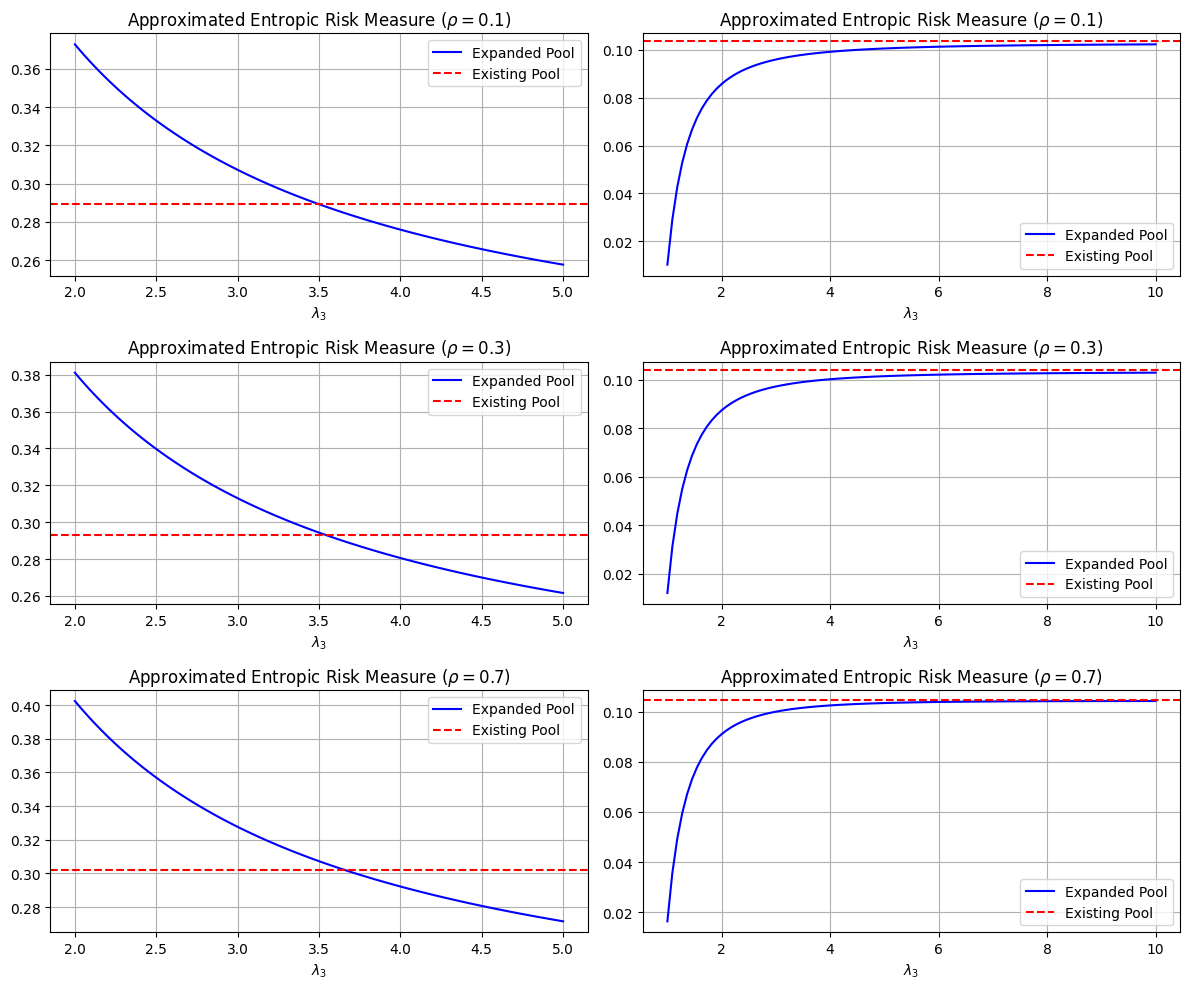

In [ ]:
# Define the number of rows and columns
rows, cols = 3, 2  # 3 rows, 2 columns

# Create a figure with subplots
fig, axes = plt.subplots(rows, cols, figsize=(12, 10))  # Adjust figure size as needed

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Ensure we do not exceed the available subplots
max_plots = rows * cols  # Maximum number of plots we can accommodate

# Left column (First three from entropic_risk_results1)
for idx, (rho, result) in enumerate(entropic_risk_results1.items()):
    if idx >= 3:  # Limit to 3 subplots for left column
        break

    entropic_risk_measures = result["entropic_risk_measures"]
    entropic_risk_baseline_avg = result["baseline_avg"]

    # Extract lambda values and corresponding averaged entropic risks
    lambda_values = list(entropic_risk_measures.keys())
    averaged_risks = list(entropic_risk_measures.values())

    # Select the correct subplot (Left column: 0, 2, 4)
    ax = axes[idx * 2]

    # Plot
    ax.plot(lambda_values, averaged_risks, label="Expanded Pool", color="blue")
    ax.axhline(y=entropic_risk_baseline_avg, color="red", linestyle="--", label="Existing Pool")

    ax.set_xlabel(r"$\lambda_{3}$")
    ax.set_title(rf"Approximated Entropic Risk Measure ($\rho={rho}$)")
    ax.legend()
    ax.grid(True)

# Right column (Next three from entropic_risk_results)
for idx, (rho, result) in enumerate(entropic_risk_results.items()):
    if idx >= 3:  # Limit to 3 subplots for right column
        break

    entropic_risk_measures = result["entropic_risk_measures"]
    entropic_risk_baseline_avg = result["baseline_avg"]

    # Extract lambda values and corresponding averaged entropic risks
    lambda_values = list(entropic_risk_measures.keys())
    averaged_risks = list(entropic_risk_measures.values())

    # Select the correct subplot (Right column: 1, 3, 5)
    ax = axes[idx * 2 + 1]

    # Plot
    ax.plot(lambda_values, averaged_risks, label="Expanded Pool", color="blue")
    ax.axhline(y=entropic_risk_baseline_avg, color="red", linestyle="--", label="Existing Pool")

    ax.set_xlabel(r"$\lambda_{3}$")
    ax.set_title(rf"Approximated Entropic Risk Measure ($\rho={rho}$)")
    ax.legend()
    ax.grid(True)

# Remove any unused subplots if fewer than 6 datasets exist
for i in range((idx + 1) * 2, max_plots):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


##Figure 6

Package

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tqdm import tqdm
from scipy.stats import norm
from scipy.special import erf  # Import erf from scipy.special

Functions

In [ ]:
# Functions
def generate_correlated_normal_samples(n, rho, sample_size):
    """
    Generates correlated normal samples for a given number of distributions, rho, and sample size.
    """
    cov_matrix = rho * np.ones((n, n)) + (1 - rho) * np.eye(n)
    normal_samples = np.random.multivariate_normal(mean=np.zeros(n), cov=cov_matrix, size=sample_size)

    # Convert normal samples to uniform samples using the CDF of the normal distribution
    uniform_samples = norm.cdf(normal_samples)

    return uniform_samples

def generate_correlated_pareto_samples(uniform_samples, shape_params, x_m):
    """
    Generate correlated Pareto samples using a Gaussian copula.
    """
    # Transform uniform samples to Pareto samples using the inverse CDF of the Pareto distribution
    pareto_samples = [
        x_m * (1 - u)**(-1 / alpha) for u, alpha in zip(uniform_samples.T, shape_params)
    ]

    return np.sum(pareto_samples, axis=0), np.array(pareto_samples)

def Entropic_MZ(S_samples, delta, delta_n, first_samples):
    """
    Calculates the modified entropic risk measure incorporating equilibrium adjustments.
    """
    # Calculate components needed for equilibrium adjustments
    mean_first_sample = np.mean(first_samples)  # Mean of the first Pareto distribution samples
    scaled_samples = S_samples / delta_n  # Scaled S_samples for covariance and variance calculations

    # Calculate the entropic risk measure with equilibrium adjustments
    entropic_risk_measure = (
        delta * np.log(np.mean(np.exp(S_samples / delta_n)))
        - delta / delta_n * np.mean(S_samples)
        + mean_first_sample
    )
    return entropic_risk_measure

# Functions
def generate_correlated_normal_samples(n, rho, sample_size):
    """
    Generates correlated normal samples for a given number of distributions, rho, and sample size.
    """
    cov_matrix = rho * np.ones((n, n)) + (1 - rho) * np.eye(n)
    normal_samples = np.random.multivariate_normal(mean=np.zeros(n), cov=cov_matrix, size=sample_size)

    # Convert normal samples to uniform samples using the CDF of the normal distribution
    uniform_samples = norm.cdf(normal_samples)

    return uniform_samples

def generate_correlated_pareto_samples(uniform_samples, shape_params, x_m):
    """
    Generate correlated Pareto samples using a Gaussian copula.
    """
    # Transform uniform samples to Pareto samples using the inverse CDF of the Pareto distribution
    pareto_samples = [
        x_m * (1 - u)**(-1 / alpha) for u, alpha in zip(uniform_samples.T, shape_params)
    ]

    return np.sum(pareto_samples, axis=0), np.array(pareto_samples)

def calculate_p(X_samples, S_samples, delta_n):
    """
    Calculate the vector p in a numerically stable way.
    """
    max_S_delta = np.max(S_samples / delta_n)
    exp_S = np.exp((S_samples / delta_n) - max_S_delta)  # Stabilized exponential
    normalization = np.mean(exp_S)
    weights = exp_S / normalization
    p = np.mean(weights[:, None] * X_samples.T, axis=0)
    return p

def generate_Y(X_samples, p, delta_n):
    """
    Transform X_samples into Y_samples.
    """
    n = len(X_samples)
    A = np.full((n, n), 1 / delta_n)
    Y_samples = np.dot(A, X_samples) - np.dot(A, p[:, None]) + p[:, None]
    return Y_samples

def entropic_risk_individual(Y_samples, delta):
    """
    Calculate the entropic risk measure in a numerically stable way.
    """
    risks = []
    for Y in Y_samples:
        # Subtract max(Y / delta) for numerical stability
        max_Y_delta = np.max(Y / delta)
        stabilized_exp = np.exp((Y / delta) - max_Y_delta)
        stabilized_mean_exp = np.mean(stabilized_exp)
        risk = delta * (np.log(stabilized_mean_exp) + max_Y_delta)
        risks.append(risk)
    return np.array(risks)

Under Fairness

In [ ]:
# Parameters
shape_params = [3, 4]  # Shape parameters (alpha_1 and alpha_2)
x_m = 1  # Scale parameter for the Pareto distributions
delta = 1       # Risk aversion parameter
delta_n = len(shape_params) * delta
rho_values = [0.1, 0.3, 0.7]  # Different correlation coefficients to plot
x_start, x_end = 2.5, 4
alpha_range = np.linspace(x_start, x_end, 100)
sample_size = 1000  # Number of samples
num_simulations = 1000  # Number of simulations for each alpha value

# Initialize results storage
entropic_risk_results1 = {rho: {"baseline_avg": None, "entropic_risk_measures": []} for rho in rho_values}

# Baseline
for rho in rho_values:
    # Calculate averaged baseline entropic risk measure with correlated distributions
    baseline_risk_measures = []
    for _ in tqdm(range(num_simulations), desc=f"Baseline Risk Calculation (rho={rho})"):
        uniform_samples = generate_correlated_normal_samples(len(shape_params), rho, sample_size)
        S_samples_baseline, first_samples_baseline = generate_correlated_pareto_samples(uniform_samples, shape_params, x_m)
        entropic_risk_baseline = Entropic_MZ(S_samples_baseline, delta, delta_n, first_samples_baseline)
        baseline_risk_measures.append(entropic_risk_baseline)

    # Average the baseline entropic risk measure
    entropic_risk_results1[rho]["baseline_avg"] = np.mean(baseline_risk_measures)

# Expanded
# Stage 2: Entropic Risk Measure Calculation for Alpha Range
for rho in rho_values:
    # Initialize storage for all entropic risk measures for this rho
    alpha_risk_measures = {additional_alpha: [] for additional_alpha in alpha_range}

    for _ in tqdm(range(num_simulations), desc=f"Simulation Processing (rho={rho})"):

        # Generate the normal sample inside the simulation loop
        uniform_samples = generate_correlated_normal_samples(len(shape_params) + 1, rho, sample_size)

        for additional_alpha in alpha_range:
            shape_params_with_additional = shape_params + [additional_alpha]
            S_samples, X_samples = generate_correlated_pareto_samples(uniform_samples, shape_params_with_additional, x_m)
            entropic_risk = Entropic_MZ(S_samples, delta, delta_n + delta, X_samples)
            alpha_risk_measures[additional_alpha].append(entropic_risk)

    # Compute the mean entropic risk measure for each alpha across all simulations
    averaged_risk_measures = {
        additional_alpha: np.mean(risks) for additional_alpha, risks in alpha_risk_measures.items()
    }

    # Store the averaged risk measures in the results
    entropic_risk_results1[rho]["entropic_risk_measures"] = averaged_risk_measures

Simulation Processing (rho=0.7): 100%|██████████| 1000/1000 [00:21<00:00, 45.86it/s]


Under Equilibrium

In [ ]:
# Parameters
shape_params = [3, 4]  # Shape parameters (alpha_1 and alpha_2)
x_m = 1  # Scale parameter for the Pareto distributions
delta = 1  # Risk aversion parameter
delta_n = len(shape_params) * delta
sample_size = 1000  # Number of samples
num_simulations = 3000  # Number of simulations for each shape parameter value
x_start, x_end = 2, 6  # Range for additional shape parameter alpha_3
alpha_range = np.linspace(x_start, x_end, 100)
rho_values = [0.1, 0.3, 0.7]  # Different correlation coefficients to plot
rho = 0.3

In [ ]:
# Initialize results storage
entropic_risk_results = {rho: {"baseline_avg": None, "entropic_risk_measures": []} for rho in rho_values}

# Stage 1: Baseline Calculation
for rho in rho_values:
    baseline_risk_measures = []
    for _ in tqdm(range(num_simulations), desc=f"Baseline Risk Calculation (rho={rho})"):
        # Generate correlated normal samples for baseline calculation
        normal_samples = generate_correlated_normal_samples(len(shape_params), rho, sample_size)
        S_samples, X_samples = generate_correlated_pareto_samples(normal_samples, shape_params, x_m)
        p_baseline = calculate_p(X_samples, S_samples, delta_n)
        Y_samples = generate_Y(X_samples, p_baseline, delta_n)
        entropic_risk_baseline = entropic_risk_individual(Y_samples, delta)[0]
        baseline_risk_measures.append(entropic_risk_baseline)

    # Compute and store average baseline entropic risk for this rho
    entropic_risk_results[rho]["baseline_avg"] = np.mean(baseline_risk_measures)

Baseline Risk Calculation (rho=0.7): 100%|██████████| 3000/3000 [00:02<00:00, 1154.02it/s]


In [ ]:
# Stage 2: Entropic Risk Measure Calculation for Alpha Range
for rho in rho_values:
    # Initialize storage for all entropic risk measures for this rho
    alpha_risk_measures = {additional_alpha: [] for additional_alpha in alpha_range}

    for simulation_idx in tqdm(range(num_simulations), desc=f"Simulation Processing (rho={rho})"):
        # Generate the normal sample inside the simulation loop
        normal_samples = generate_correlated_normal_samples(len(shape_params) + 1, rho, sample_size)

        # Loop over all additional_alpha values
        for additional_alpha in alpha_range:
            alphas_with_additional = shape_params + [additional_alpha]

            # Transform this normal sample to Pareto for the current alpha
            S_samples, X_samples = generate_correlated_pareto_samples(normal_samples, alphas_with_additional, x_m)

            # Calculate p and generate Y_samples
            p = calculate_p(X_samples, S_samples, delta_n + delta)
            Y_samples = generate_Y(X_samples, p, delta_n + delta)

            # Compute entropic risk for the current configuration
            entropic_risk = entropic_risk_individual(Y_samples, delta)[0]
            # Store the entropic risk measure for this alpha and simulation
            alpha_risk_measures[additional_alpha].append(entropic_risk)

    # Compute the mean entropic risk measure for each alpha across all simulations
    averaged_risk_measures = {
        additional_alpha: np.mean(risks) for additional_alpha, risks in alpha_risk_measures.items()
    }

    # Store the averaged risk measures in the results
    entropic_risk_results[rho]["entropic_risk_measures"] = averaged_risk_measures


Simulation Processing (rho=0.7): 100%|██████████| 3000/3000 [01:54<00:00, 26.17it/s]


Plot

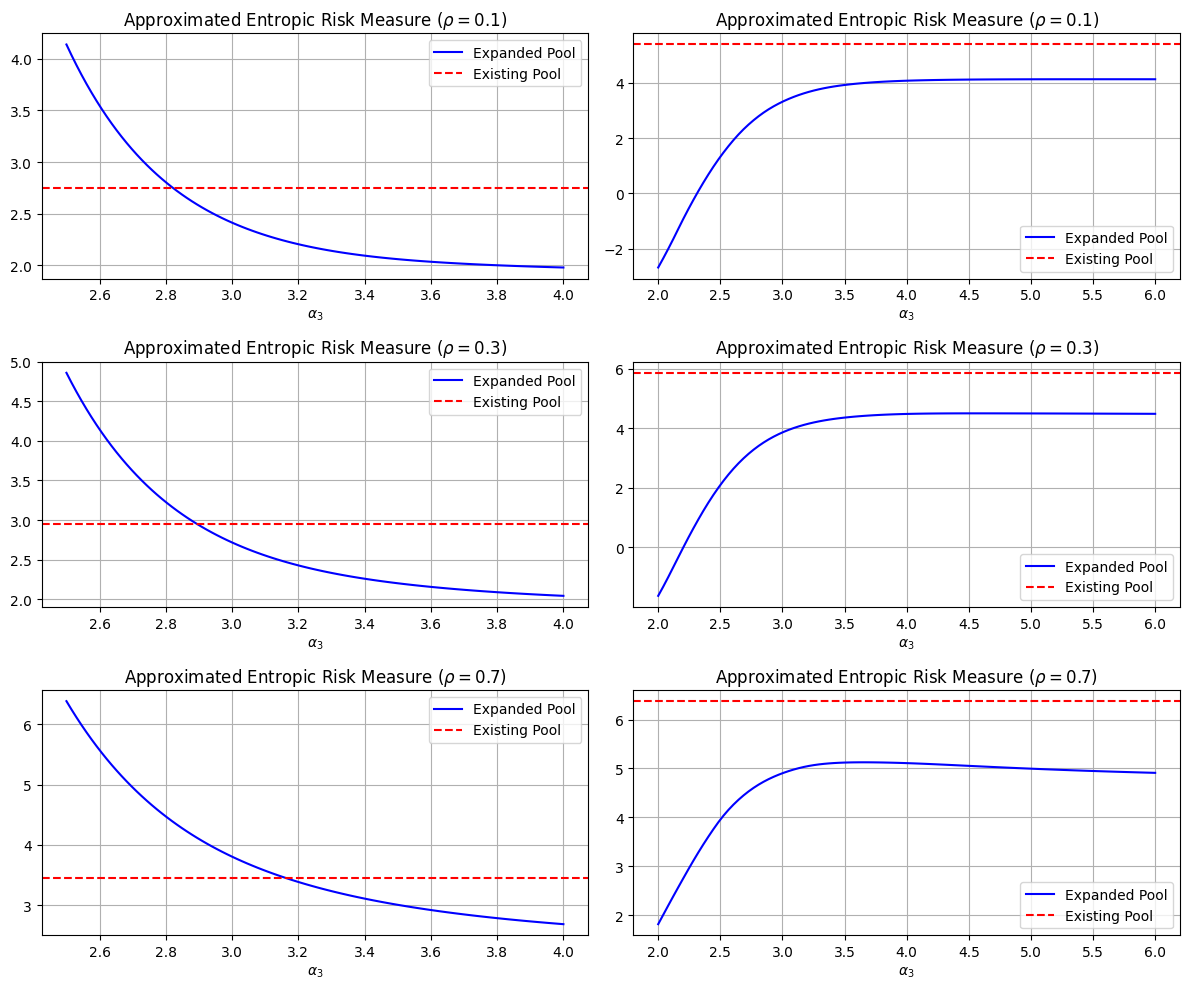

In [ ]:
# Define the number of rows and columns for the grid
rows, cols = 3, 2

# Create a figure with subplots
fig, axes = plt.subplots(rows, cols, figsize=(12, 10))
axes = axes.flatten()  # Flatten for easy indexing

# Plot results from entropic_risk_results1 (left column)
for idx, (rho, result) in enumerate(entropic_risk_results1.items()):
    if idx >= 3:  # Limit to first three plots for left column
        break

    entropic_risk_measures = result["entropic_risk_measures"]
    entropic_risk_baseline_avg = result["baseline_avg"]
    alpha_values = list(entropic_risk_measures.keys())
    averaged_risks = list(entropic_risk_measures.values())

    ax = axes[idx * 2]  # Left column (0, 2, 4)
    ax.plot(alpha_values, averaged_risks, label="Expanded Pool", color="blue")
    ax.axhline(y=entropic_risk_baseline_avg, color="red", linestyle="--", label="Existing Pool")
    ax.set_xlabel(r"$\alpha_{3}$")
    ax.set_title(rf"Approximated Entropic Risk Measure ($\rho={rho}$)")
    ax.legend()
    ax.grid(True)

# Plot results from entropic_risk_results (right column)
for idx, (rho, result) in enumerate(entropic_risk_results.items()):
    if idx >= 3:  # Limit to first three plots for right column
        break

    entropic_risk_measures = result["entropic_risk_measures"]
    entropic_risk_baseline_avg = result["baseline_avg"]
    alpha_values = list(entropic_risk_measures.keys())
    averaged_risks = list(entropic_risk_measures.values())

    ax = axes[idx * 2 + 1]  # Right column (1, 3, 5)
    ax.plot(alpha_values, averaged_risks, label="Expanded Pool", color="blue")
    ax.axhline(y=entropic_risk_baseline_avg, color="red", linestyle="--", label="Existing Pool")
    ax.set_xlabel(r"$\alpha_{3}$")
    ax.set_title(rf"Approximated Entropic Risk Measure ($\rho={rho}$)")
    ax.legend()
    ax.grid(True)

# Remove unused subplots if fewer than 6 datasets exists
for i in range((idx + 1) * 2, rows * cols):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


##Figure 7

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import gamma
from scipy.special import erf
from scipy.stats import norm

In [ ]:
# Functions
def generate_correlated_normal_samples(n, rho, sample_size):
    """
    Generates correlated normal samples for a given number of distributions, rho, and sample size.
    """
    cov_matrix = rho * np.ones((n, n)) + (1 - rho) * np.eye(n)
    normal_samples = np.random.multivariate_normal(mean=np.zeros(n), cov=cov_matrix, size=sample_size)

    # Convert normal samples to uniform samples using the CDF of the normal distribution
    uniform_samples = norm.cdf(normal_samples)

    return uniform_samples

def generate_correlated_gamma_samples(uniform_samples, shape_params, scale_params):
    """
    Generate correlated Gamma samples using a Gaussian copula.
    """
    # Transform uniform samples to Gamma samples using the inverse CDF of the Gamma distribution
    gamma_samples = [
        -np.log(1 - u) * scale / shape_params for u, scale in zip(uniform_samples.T, scale_params)
    ]

    return np.sum(gamma_samples, axis=0), np.array(gamma_samples)

def Entropic_MZ(S_samples, delta, delta_n, first_samples):
    """
    Calculates the modified entropic risk measure incorporating equilibrium adjustments.
    """
    # Calculate components needed for equilibrium adjustments
    mean_first_sample = np.mean(first_samples)  # Mean of the first Gamma distribution samples
    scaled_samples = S_samples / delta_n  # Scaled S_samples for covariance and variance calculations

    # Calculate the entropic risk measure with equilibrium adjustments
    entropic_risk_measure = (
        delta * np.log(np.mean(np.exp(S_samples / delta_n)))
        - delta / delta_n * np.mean(S_samples)
        + mean_first_sample
    )
    return entropic_risk_measure

Under fairness

In [ ]:
# Parameters for Gamma distribution
gamma_shape = 5  # Fixed shape parameter
scales = [1,2]
scale_range = np.linspace(0.1, 4, 100)  # Varying scale parameter
sample_size = 1000  # Number of samples
num_simulations = 3000  # Number of simulations for each scale parameter value
delta = 1  # Risk aversion parameter
rho_values = [0.1, 0.3, 0.7]  # Different correlation coefficients to plot
delta_n = 2 * delta  # Adjusted delta for two distributions

In [ ]:
# Results storage
gamma_risk_results1 = {rho: {"baseline_avg": None, "entropic_risk_measures": []} for rho in rho_values}

# Baseline calculation with progress tracking
for rho in rho_values:
    baseline_risk_measures = []
    with tqdm(total=num_simulations, desc=f"Baseline Risk (rho={rho})", leave=False) as pbar:
        for sim_idx in range(num_simulations):
            normal_samples = generate_correlated_normal_samples(2, rho, sample_size)  # Single Gamma distribution
            S_samples, X_samples = generate_correlated_gamma_samples(normal_samples, gamma_shape, scales)  # Fixed scale = 1

            # Compute the mean of the Gamma distribution
            mean_gamma = gamma_shape * 1  # Mean = shape * scale

            entropic_risk_baseline = Entropic_MZ(S_samples, delta, delta_n, mean_gamma)
            baseline_risk_measures.append(entropic_risk_baseline)

            # Update progress bar
            avg_risk_so_far = np.mean(baseline_risk_measures)
            pbar.set_postfix({"Avg Risk": avg_risk_so_far})
            pbar.update(1)
    gamma_risk_results1[rho]["baseline_avg"] = np.mean(baseline_risk_measures)

In [ ]:
# Entropic risk calculation for varying scales with progress tracking
for rho in rho_values:
    scale_risk_measures = {scale: [] for scale in scale_range}
    with tqdm(total=num_simulations, desc=f"Risk Simulation (rho={rho})", leave=False) as pbar:
        for simulation_idx in range(num_simulations):
            normal_samples = generate_correlated_normal_samples(3, rho, sample_size)  # Two Gamma distributions
            for scale in scale_range:
                scales_with_varying = scales + [scale]
                S_samples, X_samples = generate_correlated_gamma_samples(normal_samples, gamma_shape, scales_with_varying)

                # Compute the mean of the Gamma distribution
                mean_gamma = gamma_shape * 1  # Mean of the fixed scale Gamma distribution

                entropic_risk = Entropic_MZ(S_samples, delta, delta_n + delta, mean_gamma)
                scale_risk_measures[scale].append(entropic_risk)

            # Update progress bar
            avg_risk_for_last_scale = np.mean(scale_risk_measures[scale_range[-1]])
            pbar.set_postfix({"Last Scale Avg Risk": avg_risk_for_last_scale})
            pbar.update(1)

    # Average risks for each scale
    averaged_risk_measures = {
        scale: np.mean(risks) for scale, risks in scale_risk_measures.items()
    }
    gamma_risk_results1[rho]["entropic_risk_measures"] = averaged_risk_measures


Under equilibrium

In [ ]:
# Functions
def generate_correlated_normal_samples(n, rho, sample_size):
    """
    Generates correlated normal samples for a given number of distributions, rho, and sample size.
    """
    cov_matrix = rho * np.ones((n, n)) + (1 - rho) * np.eye(n)
    normal_samples = np.random.multivariate_normal(mean=np.zeros(n), cov=cov_matrix, size=sample_size)

    # Convert normal samples to uniform samples using the CDF of the normal distribution
    uniform_samples = norm.cdf(normal_samples)

    return uniform_samples

def generate_correlated_gamma_samples(uniform_samples, shape_params, scale_params):
    """
    Generate correlated Gamma samples using a Gaussian copula.
    """
    # Transform uniform samples to Gamma samples using the inverse CDF of the Gamma distribution
    gamma_samples = [
        -np.log(1 - u) * scale / shape_params for u, scale in zip(uniform_samples.T, scale_params)
    ]

    return np.sum(gamma_samples, axis=0), np.array(gamma_samples)

def calculate_p(X_samples, S_samples, delta_n):
    """
    Calculate the vector p in a numerically stable way.
    """
    max_S_delta = np.max(S_samples / delta_n)
    exp_S = np.exp((S_samples / delta_n) - max_S_delta)  # Stabilized exponential
    normalization = np.mean(exp_S)
    weights = exp_S / normalization
    p = np.mean(weights[:, None] * X_samples.T, axis=0)
    return p

def generate_Y(X_samples, p, delta_n):
    """
    Transform X_samples into Y_samples.
    """
    n = len(X_samples)
    A = np.full((n, n), 1 / delta_n)
    Y_samples = np.dot(A, X_samples) - np.dot(A, p[:, None]) + p[:, None]
    return Y_samples

def entropic_risk_individual(Y_samples, delta):
    """
    Calculate the entropic risk measure in a numerically stable way.
    """
    risks = []
    for Y in Y_samples:
        max_Y_delta = np.max(Y / delta)  # Stabilize for numerical safety
        stabilized_exp = np.exp((Y / delta) - max_Y_delta)
        stabilized_mean_exp = np.mean(stabilized_exp)
        risk = delta * (np.log(stabilized_mean_exp) + max_Y_delta)
        risks.append(risk)
    return np.array(risks)

In [ ]:
# Parameters for Gamma distribution
gamma_shape = 5  # Fixed shape parameter
scales = [1,2]
scale_range = np.linspace(0.1, 4, 100)  # Varying scale parameter
sample_size = 1000  # Number of samples
num_simulations = 3000  # Number of simulations for each scale parameter value
delta = 1  # Risk aversion parameter
rho_values = [0.1, 0.3, 0.7]  # Different correlation coefficients to plot
delta_n = 2 * delta  # Adjusted delta for two distributions

In [ ]:
# Initialize results storage
entropic_risk_results = {rho: {"baseline_avg": None, "entropic_risk_measures": []} for rho in rho_values}

# Stage 1: Baseline Calculation
for rho in rho_values:
    baseline_risk_measures = []
    for _ in tqdm(range(num_simulations), desc=f"Baseline Risk Calculation (rho={rho})"):
        # Generate correlated normal samples for baseline calculation
        normal_samples = generate_correlated_normal_samples(2, rho, sample_size)
        S_samples, X_samples = generate_correlated_gamma_samples(normal_samples, gamma_shape, scales)  # Fixed scale = 1
        p_baseline = calculate_p(X_samples, S_samples, delta_n)
        Y_samples = generate_Y(X_samples, p_baseline, delta_n)
        entropic_risk_baseline = entropic_risk_individual(Y_samples, delta)[0]
        baseline_risk_measures.append(entropic_risk_baseline)

    # Compute and store average baseline entropic risk for this rho
    entropic_risk_results[rho]["baseline_avg"] = np.mean(baseline_risk_measures)

Baseline Risk Calculation (rho=0.7): 100%|██████████| 3000/3000 [00:02<00:00, 1296.64it/s]


In [ ]:
# Stage 2: Entropic Risk Measure Calculation for Scale Range
for rho in rho_values:
    scale_risk_measures = {scale: [] for scale in scale_range}

    for simulation_idx in tqdm(range(num_simulations), desc=f"Expanded Processing (rho={rho})"):
        normal_samples = generate_correlated_normal_samples(3, rho, sample_size)

        for scale in scale_range:
            scales_with_varying = scales + [scale]
            S_samples, X_samples = generate_correlated_gamma_samples(normal_samples, gamma_shape, scales_with_varying)
            p = calculate_p(X_samples, S_samples, delta_n)
            Y_samples = generate_Y(X_samples, p, delta_n)

            entropic_risk = entropic_risk_individual(Y_samples, delta)[0]
            scale_risk_measures[scale].append(entropic_risk)

    averaged_risk_measures = {scale: np.mean(risks) for scale, risks in scale_risk_measures.items()}
    entropic_risk_results[rho]["entropic_risk_measures"] = averaged_risk_measures

Expanded Processing (rho=0.7): 100%|██████████| 3000/3000 [01:48<00:00, 27.58it/s]


Plot

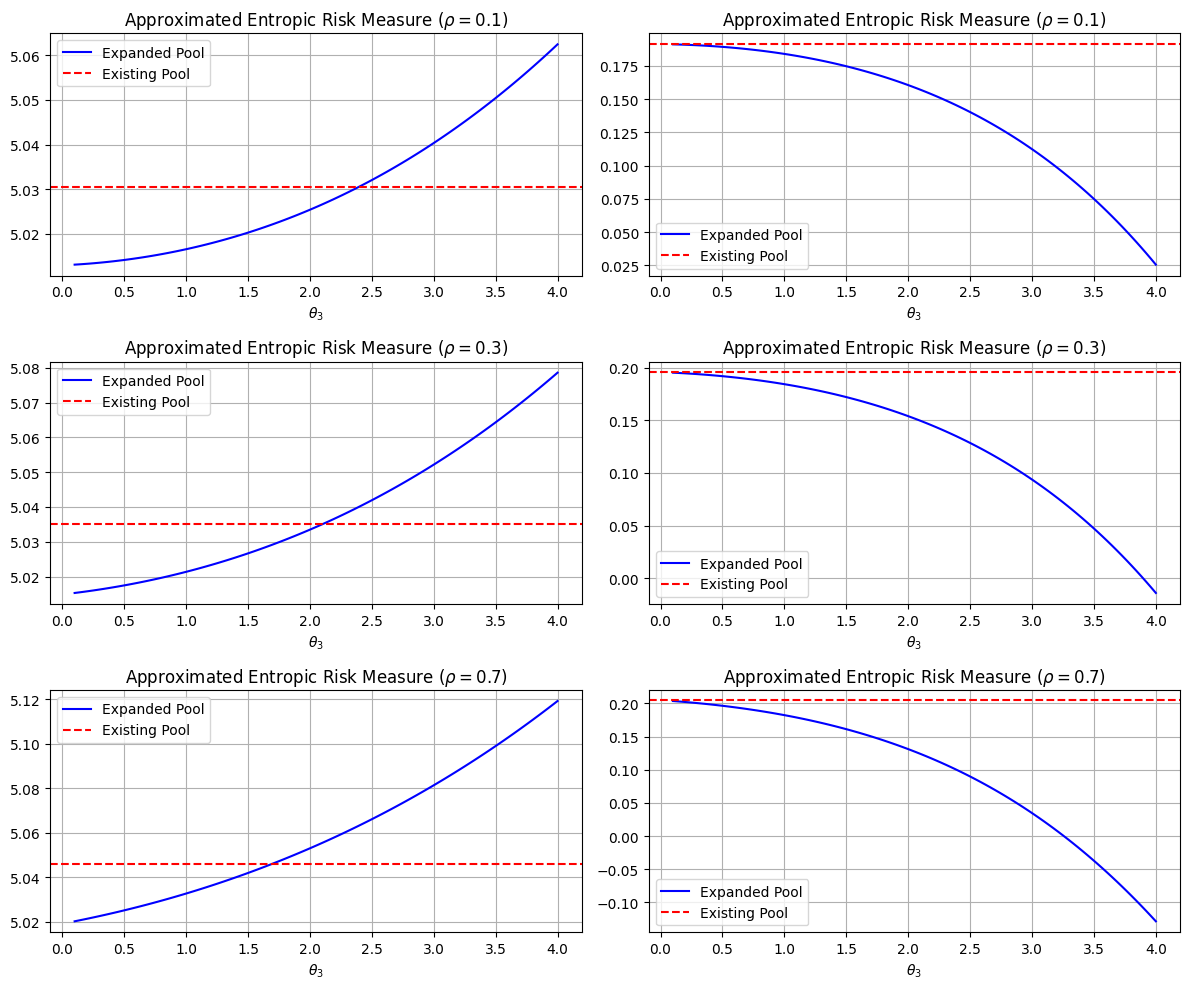

In [ ]:

# Define grid size
rows, cols = 3, 2  # 3 rows, 2 columns

# Create a figure with subplots
fig, axes = plt.subplots(rows, cols, figsize=(12, 10))  # Adjust figure size as needed

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Ensure we do not exceed the available subplots
max_plots = rows * cols  # Maximum number of plots

# Left column: First three from gamma_risk_results1
for idx, (rho, result) in enumerate(gamma_risk_results1.items()):
    if idx >= 3:  # Limit to 3 subplots for left column
        break

    entropic_risk_measures = result["entropic_risk_measures"]
    entropic_risk_baseline_avg = result["baseline_avg"]

    # Extract scale values and corresponding entropic risks
    scale_values = list(entropic_risk_measures.keys())
    averaged_risks = list(entropic_risk_measures.values())

    # Select the correct subplot (Left column: 0, 2, 4)
    ax = axes[idx * 2]

    # Plot
    ax.plot(scale_values, averaged_risks, label="Expanded Pool", color="blue")
    ax.axhline(y=entropic_risk_baseline_avg, color="red", linestyle="--", label="Existing Pool")
    ax.set_xlabel(r"$\theta_{3}$")
    ax.set_title(rf"Approximated Entropic Risk Measure ($\rho={rho}$)")
    ax.legend()
    ax.grid(True)

# Right column: Next three from entropic_risk_results
for idx, (rho, result) in enumerate(entropic_risk_results.items()):
    if idx >= 3:  # Limit to 3 subplots for right column
        break

    entropic_risk_measures = result["entropic_risk_measures"]
    entropic_risk_baseline_avg = result["baseline_avg"]

    # Extract scale values and corresponding entropic risks
    scale_values = list(entropic_risk_measures.keys())
    averaged_risks = list(entropic_risk_measures.values())

    # Select the correct subplot (Right column: 1, 3, 5)
    ax = axes[idx * 2 + 1]

    # Plot
    ax.plot(scale_values, averaged_risks, label="Expanded Pool", color="blue")
    ax.axhline(y=entropic_risk_baseline_avg, color="red", linestyle="--", label="Existing Pool")
    ax.set_xlabel(r"$\theta_{3}$")
    ax.set_title(rf"Approximated Entropic Risk Measure ($\rho={rho}$)")
    ax.legend()
    ax.grid(True)

# Remove unused subplots if there are fewer than 6 datasets
for i in range((idx + 1) * 2, max_plots):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


##Figure 8

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [ ]:
# Define the range of x and y values
x = np.linspace(-0.1, 5, 100)
y = np.linspace(-0.1, 5, 100)

# Create a grid of (x, y) points
X, Y = np.meshgrid(x, y)

In [ ]:
# Define the function l(x;beta)
def l_function(x, beta):
    term1 = np.log(np.exp(x**2/2) * norm.cdf(beta - x) + np.exp(beta * x) * norm.cdf(-beta))
    term2 = x * (norm.pdf(beta) - beta * norm.cdf(-beta))
    return term1 + term2

In [ ]:
Z = l_function(X,Y)

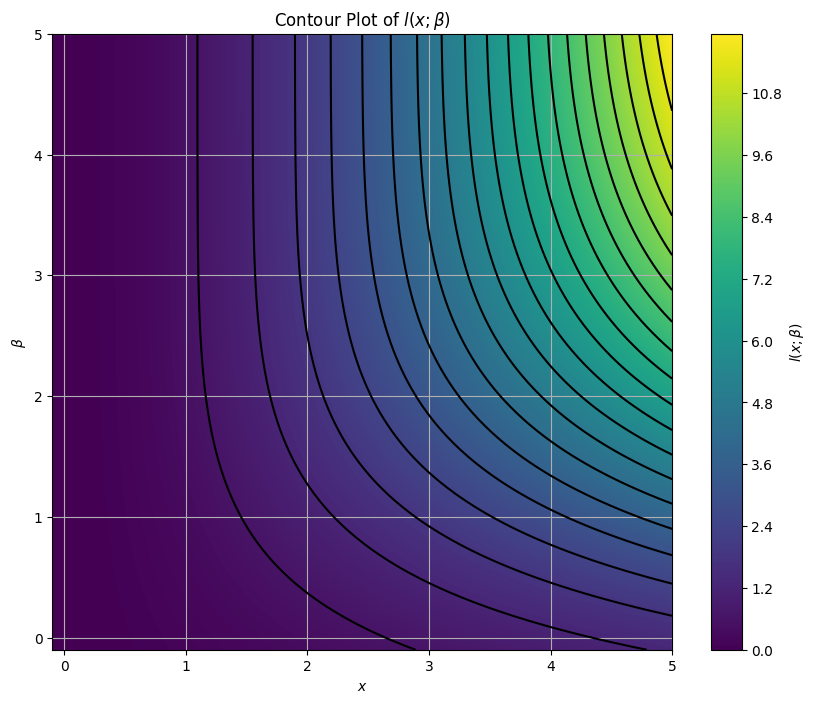

In [ ]:
# Create the filled contour plot with more levels
plt.figure(figsize=(10, 8))
contour_plot = plt.contourf(X, Y, Z, cmap='viridis', levels=1000)

# Add contour lines on top of filled regions
contour_lines = plt.contour(X, Y, Z, colors='k', levels=20)

# Add labels, title, and color bar
plt.xlabel(r'$x$')
plt.ylabel(r'$\beta$')
plt.title(r'Contour Plot of $l(x;\beta)$')
plt.colorbar(contour_plot, label=r'$l(x;\beta)$')

# Show the plot
plt.grid(True)
plt.show()

##Figure 9

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
from google.colab import files
import math
import random

In [ ]:
# Define a function
def wo_formula(x, var, cor, delt, num, index):
    # Calculate the covariance matrix with fixed pairwise correlations of (cor)
    correlation = cor
    cov = np.diag(var)
    for i in range(num):
        for j in range(i + 1, num):
            cov[i, j] = cov[j, i] = correlation * np.sqrt(var[i] * var[j])

    #Parameters
    sum_sd = np.sum(np.sqrt(var))  #\Sigma_n
    total_var = np.sum(cov)  #s_n^2
    lam_ni = delt[index]/np.sum(delt[:num]) #lambda_n,i
    lam_n1i = delt[index]/np.sum(delt) #lambda_n+1,i
    func=x**2+2*cor*(sum_sd-np.sqrt(var[index])/lam_n1i)*x+2*(lam_ni/(lam_n1i**2)-1/lam_n1i)*(var[index]+cor*np.sqrt(var[index])*(sum_sd-np.sqrt(var[index])))-((lam_ni**2)/(lam_n1i**2)-1)*total_var

    return func

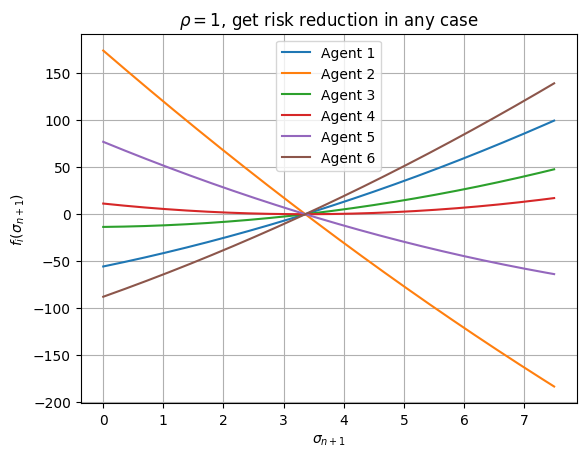

In [ ]:
x_values = np.linspace(0, 7.5, 500)
sig_list = [2.72918355, 12.57319844,  9.04263926, 19.98134713, 19.62144943,  0.24548275]
deltas = np.array([13.50949095,  7.07203475, 15.68416131, 19.20570711, 12.98515889,  7.16521784, 14.4416517])
corr = 1
for i in range(len(sig_list)):
    y_values = wo_formula(x_values, sig_list, corr, deltas, len(sig_list), i)
    # Plot each graph
    plt.plot(x_values, y_values, label=f"Agent {i+1}")

# Add labels and legend
plt.xlabel(r'$\sigma_{n+1}$')
plt.ylabel(r'$f_{i}(\sigma_{n+1})$')
plt.legend()
plt.grid(True)
plt.title(r'$\rho=1$, get risk reduction in any case')
plt.show()

##Figure 10

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
from google.colab import files
import math
import random

In [ ]:
# Define a function
def wo_formula(x, var, cor, delt, num, index):
    # Calculate the covariance matrix with fixed pairwise correlations of (cor)
    correlation = cor
    cov = np.diag(var)
    for i in range(num):
        for j in range(i + 1, num):
            cov[i, j] = cov[j, i] = correlation * np.sqrt(var[i] * var[j])

    #Parameters
    sum_sd = np.sum(np.sqrt(var))  #\Sigma_n
    total_var = np.sum(cov)  #s_n^2
    lam_ni = delt[index]/np.sum(delt[:num]) #lambda_n,i
    lam_n1i = delt[index]/np.sum(delt) #lambda_n+1,i
    func=x**2+2*cor*(sum_sd-np.sqrt(var[index])/lam_n1i)*x+2*(lam_ni/(lam_n1i**2)-1/lam_n1i)*(var[index]+cor*np.sqrt(var[index])*(sum_sd-np.sqrt(var[index])))-((lam_ni**2)/(lam_n1i**2)-1)*total_var

    return func

Text(0.5, 1.0, 'Three distinct acceptance region when common $\\sigma$')

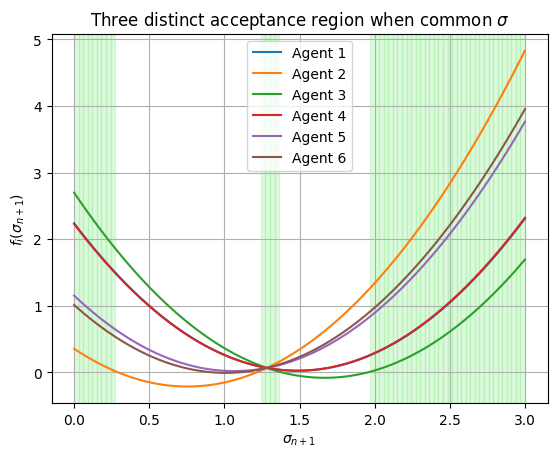

In [ ]:

sig_list = np.ones(6)
deltas = np.array([6.39996034, 7.118228,   6.24626938, 6.40343508, 6.79533862, 6.85027713,8.45727079])
corr = 0.9648994646461161
x_values = np.linspace(0, 3, 100)
# Check if all graphs are above zero for each x-value
all_above_zero = np.all([wo_formula(x_values, sig_list, corr, deltas, len(sig_list), i) > 0 for i in range(len(sig_list))], axis=0)

for i in range(len(sig_list)):
    y_values = wo_formula(x_values, sig_list, corr, deltas, len(sig_list), i)
    # Plot each graph
    plt.plot(x_values, y_values, label=f"Agent {i+1}")
# Mark the region on the x-axis where all graphs are above zero
for span_start, span_end in zip(x_values[:-1], x_values[1:]):
    if np.all(all_above_zero[(x_values >= span_start) & (x_values <= span_end)]):
        plt.axvspan(span_start, span_end, color='lightgreen', alpha=0.3)

# Add labels and legend
plt.xlabel(r'$\sigma_{n+1}$')
plt.ylabel(r'$f_{i}(\sigma_{n+1})$')
plt.legend()
plt.grid(True)
plt.title(r'Three distinct acceptance region when common $\sigma$')

##Figure 11

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
from google.colab import files
import math
import random

In [ ]:
# Define a function
def wo_formula(x, var, cor, delt, num, index):
    # Calculate the covariance matrix with fixed pairwise correlations of (cor)
    correlation = cor
    cov = np.diag(var)
    for i in range(num):
        for j in range(i + 1, num):
            cov[i, j] = cov[j, i] = correlation * np.sqrt(var[i] * var[j])

    #Parameters
    sum_sd = np.sum(np.sqrt(var))  #\Sigma_n
    total_var = np.sum(cov)  #s_n^2
    lam_ni = delt[index]/np.sum(delt[:num]) #lambda_n,i
    lam_n1i = delt[index]/np.sum(delt) #lambda_n+1,i
    func=x**2+2*cor*(sum_sd-np.sqrt(var[index])/lam_n1i)*x+2*(lam_ni/(lam_n1i**2)-1/lam_n1i)*(var[index]+cor*np.sqrt(var[index])*(sum_sd-np.sqrt(var[index])))-((lam_ni**2)/(lam_n1i**2)-1)*total_var

    return func

In [ ]:
#############   w/o R Function #####################
# Set random seeds for reproducibility
# np.random.seed(0)

# Define the number of agents
var = np.array([9,169],dtype=float)
corr = 0.2
deltas = np.array([1,1,1],dtype=float)

# condition
x = np.linspace(-1, 20, 100)
y1_1 = wo_formula(x, var, corr, deltas, 2, 0)
y1_2 = wo_formula(x, var, corr, deltas, 2, 1)

Plot (Figure 11.a)

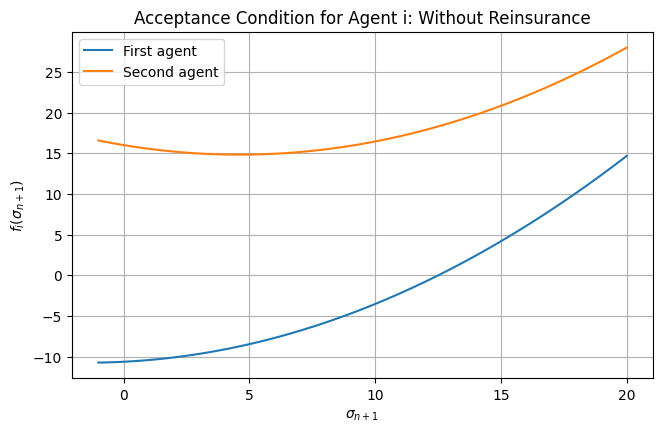

In [ ]:
#Plot all together

plt.figure(figsize=(7.5, 4.5))

# Plot, w/o R function
plt.plot(x,y1_1/18,label='First agent')
plt.plot(x,y1_2/18,label='Second agent')

plt.legend()
plt.xlabel(r'$\sigma_{n+1}$')
plt.ylabel(r'$f_i(\sigma_{n+1})$')
plt.title('Acceptance Condition for Agent i: Without Reinsurance')
plt.grid(True)
# plt.savefig('20240105_wo_rein.jpg')
plt.show()
# files.download('20240105_wo_rein.jpg')

In [ ]:
def wi_monte(data, K, n):
    x_values = data[:, 0]
    y_values = data[:, 1]
    y_values_trun = np.array([min(element, K) for element in y_values])

    fn1= np.log(np.mean(np.exp(y_values_trun/n)))
    fn2= np.mean(x_values * np.exp(y_values_trun / n))/np.mean(np.exp(y_values_trun/n))
    fn3= np.mean(y_values * np.exp(y_values_trun / n))/np.mean(np.exp(y_values_trun/n))*(1/n)
    fn4= np.mean([max(element-K,0) for element in y_values])*(1/n)

    result=fn1+fn2-fn3+fn4
    return result

In [ ]:
def get_sample_wR(s3,mean,var,beta, rho,size_sample):

    s1=np.sqrt(var[0])
    s2=np.sqrt(var[1])
    u1=mean[0]
    u2=mean[1]
    u3=mean[2]

    k2=u1+u2+beta*np.sqrt(s1**2+s2**2+2*rho*(s1*s2))
    k3=u1+u2+u3+beta*np.sqrt(s1**2+s2**2+s3**2+2*rho*(s1*s2+s2*s3+s3*s1))

    # Parameters for the bivariate normal distribution with n, X1 and Sn
    mean_vector = np.array([u1, u1+u2])
    covariance_matrix = np.array([[s1**2, s1**2+rho*s1*s2], [s1**2+rho*s1*s2, s1**2+s2**2+2*rho*s1*s2]])

    # Generate random samples from the normal distribution with n, X1 and Sn
    samples_n = multivariate_normal.rvs(mean=mean_vector, cov=covariance_matrix, size=size_sample)

    # Parameters for the bivariate normal distribution with n+1, X1 and Sn
    mean_vector1 = np.array([u1, u1+u2+u3])
    covariance_matrix1 = np.array([[s1**2, s1**2+rho*s1*s2+rho*s1*s3], [s1**2+rho*s1*s2+rho*s1*s3, s1**2+s2**2+s3**2+2*rho*(s1*s2+s2*s3+s3*s1)]])

    # Generate random samples from the normal distribution with n+1, X1 and Sn
    samples_n1 = multivariate_normal.rvs(mean=mean_vector1, cov=covariance_matrix1, size=size_sample)

    return samples_n, samples_n1, k2, k3

In [ ]:
def get_sample_wR2(s3,mean,var,beta, rho,size_sample):

    s1=np.sqrt(var[0])
    s2=np.sqrt(var[1])
    u1=mean[0]
    u2=mean[1]
    u3=mean[2]

    k2=u1+u2+beta*np.sqrt(s1**2+s2**2+2*rho*(s1*s2))
    k3=u1+u2+u3+beta*np.sqrt(s1**2+s2**2+s3**2+2*rho*(s1*s2+s2*s3+s3*s1))

    # Parameters for the bivariate normal distribution with n, X1 and Sn
    mean_vector = np.array([u2, u1+u2])
    covariance_matrix = np.array([[s2**2, s2**2+rho*s2*s1], [s2**2+rho*s2*s1, s2**2+s1**2+2*rho*s2*s1]])

    # Generate random samples from the normal distribution with n, X1 and Sn
    samples_n = multivariate_normal.rvs(mean=mean_vector, cov=covariance_matrix, size=size_sample)

    # Parameters for the bivariate normal distribution with n+1, X1 and Sn
    mean_vector1 = np.array([u2, u1+u2+u3])
    covariance_matrix1 = np.array([[s2**2, s2**2+rho*s2*s1+rho*s2*s3], [s2**2+rho*s2*s1+rho*s2*s3, s2**2+s1**2+s3**2+2*rho*(s2*s1+s1*s3+s3*s2)]])

    # Generate random samples from the normal distribution with n+1, X1 and Sn
    samples_n1 = multivariate_normal.rvs(mean=mean_vector1, cov=covariance_matrix1, size=size_sample)

    return samples_n, samples_n1, k2, k3

In [ ]:
#############   w/R Monte #####################

#Parameters
Nsamplesize = 1000
Amean = np.array([5,9,5],dtype=float)
Avar = np.array([9,169],dtype=float)
Adeltas = np.array([1,1,1],dtype=float)
Ncorr = 0.2
Nexist = 2
As3=np.linspace(0,20,100)
Nbeta=0.7125
trial=1000

In [ ]:
result = np.zeros(len(As3), dtype=float)
for i in range(trial):
    result_temp=[]
    for s3 in As3:
        # samples
        Asample_XiSn, Asample_XiSn1, k2, k3 = get_sample_wR(s3, Amean, Avar, Nbeta, Ncorr, Nsamplesize)

        # Utility with insurance
        U_n=wi_monte(Asample_XiSn,k2,2)
        U_n1=wi_monte(Asample_XiSn1,k3,3)
        result_temp.append(U_n-U_n1)
    result += np.array(result_temp, dtype=float)/trial

In [ ]:
result2 = np.zeros(len(As3), dtype=float)
for i in range(trial):
    result2_temp=[]
    for s3 in As3:
        # samples
        Asample_XiSn, Asample_XiSn1, k2, k3 = get_sample_wR2(s3, Amean, Avar, Nbeta, Ncorr, Nsamplesize)

        # Utility with insurance
        U_n=wi_monte(Asample_XiSn,k2,2)
        U_n1=wi_monte(Asample_XiSn1,k3,3)
        result2_temp.append(U_n-U_n1)
    result2 += np.array(result2_temp, dtype=float)/trial

Plot (Figure 11.b)

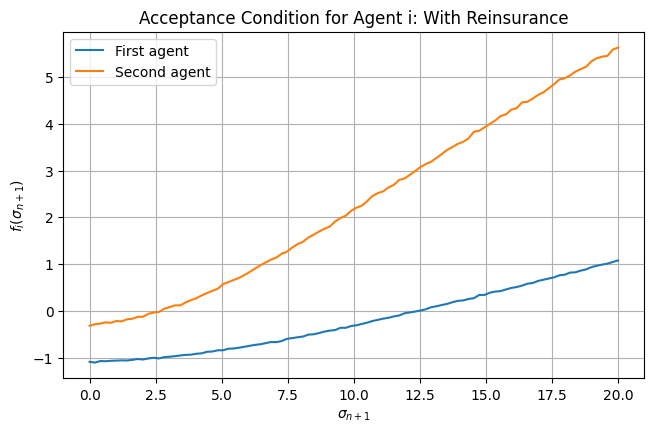

In [ ]:
#Plot all together

plt.figure(figsize=(7.5, 4.5))
plt.plot(As3,result, label=r'First agent')
plt.plot(As3,result2, label=r'Second agent')

plt.legend()
plt.xlabel(r'$\sigma_{n+1}$')
plt.ylabel(r'$f_i(\sigma_{n+1})$')
plt.title('Acceptance Condition for Agent i: With Reinsurance')
plt.grid(True)
# plt.savefig('20240105_wo_rein.jpg')
plt.show()
# files.download('20240105_wo_rein.jpg')